In [2]:
import pandas as pd
import os
import polars as pl
import joblib
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
import math
import matplotlib.gridspec as gridspec
import mplhep as hep
from scipy import stats
# Apply generic ROOT style for standard HEP formatting without collaboration labels
hep.style.use(hep.style.ROOT)



helpers_path = os.path.join('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

In [3]:
selection = "ATLAS"
LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
MODELS_DIR = f"Eval_CWoLa_SR_{selection}_ver2/"
model_path = f"Models_Extrapolation_{selection}_ver2"

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"
N_ENSEMBLE = 10
context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

scaler = joblib.load(SCALER_PATH)
device = torch.device("cpu")

In [4]:
def load_signal(mode_str, detector_mode,  base_path=SIGNAL_DIR):

    file_path = os.path.join(base_path, "SR", f"bsm_{mode_str}_{detector_mode}.parquet")
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None
        
    print(f"Loading Signal: {mode_str}... from {file_path}")
    sig_pre_cols = [
        "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
        "ht", "met_recalc_pt", "mjj"
    ]
    df_sim = pd.read_parquet(file_path, columns=sig_pre_cols)
    row = DF_META[(DF_META['Mass'] == int(mode_str.split("_")[0])) & (DF_META['Rinv'] == int(mode_str.split("_")[1]))]
    xs_eff, theory_unc = row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG

    df_sim['weight'] = norm_factor
    
    # 3. Rename columns to map directly to your SR data features
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt", # Or keep "met" if your main SR data uses "met" instead
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    # 4. Convert to Polars DataFrame to match your df_mc and df_data

    print(f"  -> Loaded {len(df_sim)} generated events.")
    print(f"  -> Total expected yield (Lumi = {LUMI} fb^-1): {df_sim['final_weight'].sum():.2f} events.")
    
    return df_sim


In [5]:
def plot_signal_events(signal_events, weight_col):
    print(f"Signal events shape: {signal_events.shape}")

    bins = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for var in context_vars + features_vars:
        # Create a figure with two vertically stacked panels
        # Signal
        signal_arr = signal_events[var].to_numpy()
        signal_weights = signal_events[weight_col].to_numpy()
        counts_sig, _ = np.histogram(signal_arr, bins=bins, weights=signal_weights)

        plt.stairs(counts_sig, bins, fill = True, color= 'red')

        plt.show()

def apply_sr_cuts(df):
    return df[
        (df["ht"] > 600) & 
        (df["met_recalc_pt"] > 600) & 
        (df["met_recalc_pt"] < 2000) & 
        (df["mjj"] < 10000) & 
        (df["ht"] < 4000)
    ]

def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def score_BSM(df, bkg_type, k = 5):
    features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

    sig_events_to_score = df[features_vars].values
    # print(sig_events_to_score.shape)
    all_scores = []
    # Load model
    for i in range(k):
        model_name = f"model_Data_vs_{bkg_type}_ATLAS_fold{i + 1}.pt"
        NN = torch.load(f"{MODELS_DIR}/kfold/{model_name}", map_location=DEVICE, weights_only=False)
        NN.model.eval()

        scores_sig = NN.evaluation(sig_events_to_score).flatten()
        all_scores.append(scores_sig)
        # print(len(scores_sig))
    # print(len(np.median(all_scores, axis = 0)))
    df[f"bsm_score_{bkg_type}"] = np.median(all_scores, axis = 0)
    return df

def bkg_score_plot(df_data, df_bkg, data_score_colname, bkg_score_colname, bkg_weight_name):
    bkg_name = data_score_colname.split("_")[-1].title()
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # Clean missing values
    data_scores = df_data[data_score_colname].dropna()
    bkg_scores = df_bkg[bkg_score_colname].dropna()
    
    # Force identical bin edges across both distributions
    min_val = 0
    max_val = 1
    bin_edges = np.linspace(min_val, max_val, 50)
    
    # Plot background and capture counts
    counts_bkg, _, _ = ax1.hist(
        bkg_scores, 
        bins=bin_edges, 
        alpha=0.4, 
        color="#1f77b4", 
        edgecolor="#1f77b4",
        label=f"{bkg_name} (Hist)",
        histtype="stepfilled", 
        weights=df_bkg[bkg_weight_name]
    )
    
    # Plot data and capture counts
    counts_data, _, _ = ax1.hist(
        data_scores, 
        bins=bin_edges, 
        alpha=0.4, 
        color="#d62728", 
        edgecolor="#d62728",
        label="Data (Hist)",
        histtype="stepfilled"
    )
    
    # --- CDF CALCULATION ---
    cdf_bkg = np.cumsum(counts_bkg) / np.sum(counts_bkg)
    cdf_data = np.cumsum(counts_data) / np.sum(counts_data)
    
    # --- KS MAXIMUM DIFFERENCE CALCULATION ---
    # Calculate the absolute difference between the two CDFs
    cdf_diff = np.abs(cdf_data - cdf_bkg)
    
    # Find the index of the maximum difference
    max_diff_idx = np.argmax(cdf_diff)
    
    # Find the corresponding x-value (using the right edge of the bin)
    optimal_cut = bin_edges[max_diff_idx + 1] 
    max_diff_value = cdf_diff[max_diff_idx]
    
    # --- SECONDARY AXIS FOR CDF ---
    ax2 = ax1.twinx()
    ax2.plot(bin_edges[1:], cdf_bkg, color="blue", linestyle="-", linewidth=2, label=f"{bkg_name} (CDF)")
    ax2.plot(bin_edges[1:], cdf_data, color="red", linestyle="--", linewidth=2, label="Data (CDF)")
    
    # Highlight the maximum CDF difference (KS Cut)
    ax1.axvline(
        optimal_cut, 
        color="green", 
        linestyle=":", 
        linewidth=2.5, 
        label=f"Max CDF Diff Cut: {optimal_cut:.2f}"
    )
    
    # Optionally draw a small vertical line connecting the two CDFs at the max difference
    ax2.plot(
        [optimal_cut, optimal_cut], 
        [cdf_bkg[max_diff_idx], cdf_data[max_diff_idx]], 
        color="green", 
        linewidth=3
    )

    # Formatting for ax1
    ax1.set_xlabel("Classifier Score", fontsize=11)
    ax1.set_ylabel("Count (Log Scale)", fontsize=11)
    ax1.set_yscale("log")
    ax1.grid(True, linestyle="--", alpha=0.4)
    
    # Formatting for ax2
    ax2.set_ylabel("Cumulative Probability", fontsize=11)
    ax2.set_ylim(0, 1.05)
    
    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center left", frameon=True, facecolor="white", edgecolor="none", fontsize=10)
    
    plt.title(f"Classifier Score & KS Cut: Data vs. {bkg_name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    print(f"The maximum CDF difference is {max_diff_value:.4f} at a classifier score of {optimal_cut:.4f}")
    return optimal_cut

def process_bsm_signal(sig_id, mode):
    """Loads and processes a single signal dataset."""
    df = load_signal(sig_id, mode)
    df = apply_sr_cuts(df)
    df = transform(df)
    df = score_BSM(df, "Nom")
    df = score_BSM(df, "Reweight_Median")
    df = score_BSM(df, "Generate_Combined")
    return df

In [6]:
# Load SR Data and Background (Nomnial, Reweight, and Generate)

df_data = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_reweighted_scored.parquet")
nominal_w = df_mc_rw["final_weight"].values
rw_ensemble_weights = [df_mc_rw[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
df_mc_rw["rw_mediam_weights"] = nominal_w * rw_median

gen_dfs = []
for i in range(N_ENSEMBLE):
    # Note: enumerate started at 0 in your saving script, so it's ens0 to ens4
    df = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_Generate_ens{i}_scored.parquet")
    
    # Scale the weights directly in the dataframe
    df['total_weight'] = df['total_weight'] / 10
    
    gen_dfs.append(df)
df_mc_gen = pd.concat(gen_dfs, ignore_index=True)

In [24]:
# Invert Scores
df_data['score_vs_nominal'] = 1.0 - df_data['score_vs_nominal']
df_data['score_vs_reweighted'] = 1.0 - df_data['score_vs_reweighted']
df_data['score_vs_generate'] = 1.0 - df_data['score_vs_generate']

df_mc_rw['score_vs_data'] = 1.0 - df_mc_rw['score_vs_data']
df_mc_rw['score_vs_reweighted_data'] = 1.0 - df_mc_rw['score_vs_reweighted_data']

df_mc_gen['score_vs_data'] = 1.0 - df_mc_gen['score_vs_data']

In [7]:
# nom_cut_cdf = bkg_score_plot(df_data, df_mc_rw, "score_vs_nominal", "score_vs_data", "final_weight")

In [8]:
# rw_cut_cdf = bkg_score_plot(df_data, df_mc_rw, "score_vs_reweighted", "score_vs_reweighted_data", "rw_mediam_weights")

In [9]:
# gen_cut_cdf = bkg_score_plot(df_data, df_mc_gen, "score_vs_generate", "score_vs_data", "total_weight")

In [10]:
SIGNAL_MODES = [
    "1000_2",
    "1000_4",
    "1000_6",
    "1000_8",
    "2000_2",
    "2000_4",
    "2000_6",
    "2000_8",
    "3000_2",
    "3000_4",
    "3000_6",
    "3000_8"
]

In [11]:
detector_modes = ["default", "pu", "run2", "pu_run2"]
sig_dfs = {mode: {} for mode in detector_modes}

for mode in detector_modes:
    for sig_id in SIGNAL_MODES:
        # This runs your pipeline and stores it perfectly organized
        sig_dfs[mode][sig_id] = process_bsm_signal(sig_id, mode)

Loading Signal: 1000_2... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_2_default.parquet
  -> Loaded 3027 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 7338.88 events.
Loading Signal: 1000_4... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_4_default.parquet
  -> Loaded 6949 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 16828.26 events.
Loading Signal: 1000_6... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_6_default.parquet
  -> Loaded 11480 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 27835.87 events.
Loading Signal: 1000_8... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_8_default.parquet
  -> Loaded 16409 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 39795.68 events.
Loading Signal: 2000_2... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_v

  -> Loaded 10092 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 36.38 events.
Loading Signal: 3000_6... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_3000_6_default.parquet
  -> Loaded 13404 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 48.35 events.
Loading Signal: 3000_8... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_3000_8_default.parquet
  -> Loaded 13920 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 50.39 events.
Loading Signal: 1000_2... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_2_pu.parquet
  -> Loaded 3401 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 8245.63 events.
Loading Signal: 1000_4... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_4_pu.parquet
  -> Loaded 8046 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 19484.85 events.
Loading

In [12]:
detector_type = "default" # default, pu, run2, pu_run2
df_sig_def = sig_dfs[detector_type]

In [13]:
def plot_sig_kin(df_data, df_bkg, df_sig, bkg_type, sig_mode):

    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    row1_vars = ['ht', 'met', 'score']
    row2_vars = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

    log_vars = ['mjj', 'ht', 'met', 'score']
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'score': f'Anomaly Score ({bkg_type})',
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    fig = plt.figure(figsize=(24, 12))

    gs_outer = fig.add_gridspec(2, 1, hspace=0.35)

    gs_top = gs_outer[0].subgridspec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.25)
    gs_bot = gs_outer[1].subgridspec(2, 5, height_ratios=[3, 1], hspace=0.05, wspace=0.3)

    def draw_variable(var, gs_inner, col_idx):
        if var == "score":
            density = True
            bins = np.arange(0, 1, 1/50)
        else:
            density = False
            bins = np.arange(-3, 3, 0.25)
        d_col = data_col_score if var == 'score' else var
        b_col = bkg_col_score if var == 'score' else var
        s_col = sig_col_score if var == 'score' else var
        
        var_name = var
        if d_col not in df_data.columns and var == 'met' and 'met_recalc_pt' in df_data.columns:
            d_col, b_col, s_col = 'met_recalc_pt', 'met_recalc_pt', 'met_recalc_pt'
            var_name = 'met_recalc_pt'

        data_arr = df_data[d_col].to_numpy()
        bkg_arr = df_bkg[b_col].to_numpy()
        sig_arr = df_sig[s_col].to_numpy()
        bkg_weights = df_bkg[bkg_weight_name].to_numpy()
        sig_weights = df_sig["final_weight"]

        bin_centers = (bins[:-1] + bins[1:]) / 2

        ax_main = fig.add_subplot(gs_inner[0, col_idx])
        ax_ratio = fig.add_subplot(gs_inner[1, col_idx], sharex=ax_main)

        # --- DATA ---
        counts_data, _ = np.histogram(data_arr, bins=bins, density=density)
        data_errors = np.sqrt(counts_data)
        std_data = np.std(data_arr)
        valid = counts_data > 0
        
        if var == "score":
            ax_main.errorbar(bin_centers, counts_data, fmt='ko', label='Data', zorder=10, capsize=0, markersize=4)
            data_ratio_err = np.zeros_like(counts_data, dtype=float)
            data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
            ax_ratio.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), fmt='ko', zorder=10, capsize=0, markersize=4)
            ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        else:    
            ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Data', zorder=10, capsize=0, markersize=4)
            data_ratio_err = np.zeros_like(counts_data, dtype=float)
            data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
            ax_ratio.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), yerr=data_ratio_err[valid], fmt='ko', zorder=10, capsize=0, markersize=4)
            ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # --- BACKGROUND ---
        counts_bkg, _ = np.histogram(bkg_arr, bins=bins, weights=bkg_weights, density=density)
        ax_main.stairs(counts_bkg, bins, fill=True, color="grey", alpha=0.5, label=f'SM Background')
        
        ratio_bkg = np.divide(counts_bkg, counts_data, out=np.full_like(counts_bkg, np.nan, dtype=float), where=valid)
        ax_ratio.stairs(ratio_bkg, bins, color="grey", alpha=0.8)

        # --- SIGNAL ---
        counts_sig, _ = np.histogram(sig_arr, bins=bins, weights=sig_weights, density=density)
        ax_main.stairs(counts_sig, bins, color="red", linewidth=2, linestyle='-', label='Signal (BSM)')


        # if var in log_vars:
        ax_main.set_yscale('log')

        ymin, ymax = ax_main.get_ylim()
        if var in log_vars:

            ax_main.set_ylim(ymin, ymax) 
        else:
            ax_main.set_ylim(ymin, ymax * 1.5)

        if col_idx == 0:
            ax_main.set_ylabel('Events', fontsize=12)
            ax_ratio.set_ylabel('Bkg/Data', fontsize=10)
        
        ax_main.legend(frameon=False, fontsize=9, loc='upper right')
        plt.setp(ax_main.get_xticklabels(), visible=False) # Hide x-ticks on main plot

        ax_ratio.set_ylim(0.5, 1.5) 
        ax_ratio.set_xlabel(pretty_labels.get(var_name, var_name), fontsize=12)
        ax_ratio.tick_params(axis='x', which='both', bottom=True, top=True)
        ax_ratio.grid(True, axis='y', linestyle=':', alpha=0.6)


    for i, var in enumerate(row1_vars):
        draw_variable(var, gs_top, i)
        

    for i, var in enumerate(row2_vars):
        draw_variable(var, gs_bot, i)

    title_text = (
        r"Kinematic Distributions ($M_\phi = "
        + str(sig_mode.split("_")[0])
        + r"\text{ GeV}$, $R_{\text{inv}} = 0."
        + str(sig_mode.split("_")[1])
        + r"$)"
    )

    fig.suptitle(title_text, fontsize=20, fontweight="bold", y=0.95)
    plt.show()

In [14]:
bkg_type = "GEN" # NOM, RW, GEN

for sig_mode in SIGNAL_MODES:
    if bkg_type == "GEN":
        df_mc = df_mc_gen
    else:
        df_mc = df_mc_rw
    # plot_sig_kin(df_data, df_mc, df_sig_def[sig_mode], bkg_type=bkg_type, sig_mode = sig_mode)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

def plot_sr_closure(df_data, df_bkg, bkg_type, features, target_bkg_eff=0.05):
    """
    Plots the Data vs Background agreement at a specific model-independent working point.
    
    Parameters:
    - df_data: DataFrame containing data events
    - df_bkg: DataFrame containing background estimation events
    - bkg_type: 'NOM', 'RW', or 'GEN'
    - features: List of feature column names to plot
    - target_bkg_eff: The fraction of highest-scoring background to keep (default: 0.05 for 5%)
    
    Returns:
    - best_threshold: The score cut corresponding to the target background efficiency
    """
    
    # 1. Setup based on background type
    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        bkg_weight_name = "final_weight"
        bkg_label = "Nominal MC"
        color = "#1f77b4" # Blue
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        bkg_weight_name = "rw_mediam_weights" 
        bkg_label = "Reweighted (SALAD-like)"
        color = "#2ca02c" # Green
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        bkg_weight_name = "total_weight"
        bkg_label = "Generated (CATHODE-like)"
        color = "#ff7f0e" # Orange
    else:
        raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")

    # 2. Calculate the threshold based on Background Percentile
    bkg_scores = df_bkg[bkg_col_score].values
    bkg_weights = df_bkg[bkg_weight_name].values
    
    # Sort scores and weights to find the exact cut value based on cumulative sum
    sort_idx = np.argsort(bkg_scores)
    sorted_scores = bkg_scores[sort_idx]
    sorted_weights = np.abs(bkg_weights[sort_idx]) # Use absolute weights for cumulative sum
    
    cum_weights = np.cumsum(sorted_weights)
    if cum_weights[-1] == 0:
        raise ValueError("Total background weight is zero. Cannot compute threshold.")
        
    cum_weights_norm = cum_weights / cum_weights[-1]
    
    # We want to KEEP the top target_bkg_eff, meaning we cut out (1 - target_bkg_eff)
    cut_fraction = 1.0 - target_bkg_eff
    
    # Find the first index where the cumulative weight exceeds the cut fraction
    threshold_idx = np.searchsorted(cum_weights_norm, cut_fraction)
    
    # Protect against out-of-bounds
    if threshold_idx >= len(sorted_scores):
        threshold_idx = len(sorted_scores) - 1
        
    best_threshold = sorted_scores[threshold_idx]
    
    print(f"--- Model-Independent Working Point ---")
    print(f"Target Background Efficiency: {target_bkg_eff*100:.1f}%")
    print(f"Calculated Threshold: {best_threshold:.4f}")

    # 3. Filter events ONCE using this predefined threshold
    data_events = df_data[df_data[data_col_score] > best_threshold]
    bkg_events = df_bkg[df_bkg[bkg_col_score] > best_threshold]

    num_features = len(features)
    
    # 4. Create a 2 x N grid of subplots
    fig, axes = plt.subplots(
        2, num_features, 
        figsize=(6 * num_features, 7), 
        sharex='col', 
        gridspec_kw={'height_ratios': [3, 1]},
        squeeze=False 
    )

    fig.suptitle(
        f"High Anomaly Score Validation ({bkg_type})\n"
        f"Threshold: {best_threshold:.3f} (Top {target_bkg_eff*100:.1f}% of Background)", 
        fontsize=14, fontweight="bold"
    )

    # 5. Loop through each feature and plot using Chi2
    for i, feature in enumerate(features):
        ax1 = axes[0, i] 
        ax2 = axes[1, i] 

        # Safely extract feature data and weights, dropping NaNs to prevent index misalignment
        valid_data_idx = data_events[feature].dropna().index
        valid_bkg_idx = bkg_events[feature].dropna().index
        
        f_data = data_events.loc[valid_data_idx, feature].values
        f_bkg = bkg_events.loc[valid_bkg_idx, feature].values
        w_bkg = bkg_events.loc[valid_bkg_idx, bkg_weight_name].values
        
        bin_edges = np.arange(-3.0, 3.0, 0.25)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        counts_data, _ = np.histogram(f_data, bins=bin_edges)
        counts_bkg, _ = np.histogram(f_bkg, bins=bin_edges, weights=w_bkg)

        err_data = np.sqrt(counts_data)
        err_bkg = np.sqrt(np.histogram(f_bkg, bins=bin_edges, weights=w_bkg**2)[0])

        # --- Calculate Binned Chi-Square for Agreement ---
        # Only evaluate bins where we expect some background
        valid_bins = (counts_bkg > 0)
        
        if np.sum(valid_bins) > 1:
            variance = err_data[valid_bins]**2 + err_bkg[valid_bins]**2
            safe_variance_mask = variance > 0
            
            if np.sum(safe_variance_mask) > 1:
                chi2_val = np.sum(
                    (counts_data[valid_bins][safe_variance_mask] - counts_bkg[valid_bins][safe_variance_mask])**2 / 
                    variance[safe_variance_mask]
                )
                ndof = np.sum(safe_variance_mask) - 1
                p_value = chi2.sf(chi2_val, ndof)
            else:
                p_value = 0.0
        else:
            p_value = 0.0

        # --- Main Plot (ax1) ---
        ax1.hist(
            f_bkg, bins=bin_edges, weights=w_bkg,
            alpha=0.5, color=color, label=bkg_label, histtype="stepfilled"
        )
        ax1.errorbar(
            bin_centers, counts_data, yerr=err_data, 
            fmt='ko', label="Data", capsize=2, elinewidth=1
        )
        
        # Display the p-value
        ax1.text(
            0.05, 0.95, f"$\chi^2$ p-val: {p_value:.3f}", 
            transform=ax1.transAxes, fontsize=11, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
        )

        ax1.set_title(f"Feature: {feature}", fontsize=12)
        ax1.legend(loc='upper right', frameon=True, fontsize=10)
        ax1.grid(True, linestyle="--", alpha=0.3)
        ax1.set_xlim(-3.0, 2.75) 

        if i == 0:
            ax1.set_ylabel("Events", fontsize=11)

        # --- Ratio Plot (ax2) ---
        ratio = np.divide(counts_data, counts_bkg, out=np.zeros_like(counts_data, dtype=float), where=counts_bkg!=0)
        ratio_err = np.divide(err_data, np.abs(counts_bkg), out=np.zeros_like(err_data, dtype=float), where=counts_bkg!=0)

        ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko', capsize=2, elinewidth=1)
        ax2.axhline(1.0, color='red', linestyle='--', alpha=0.7) 
        ax2.set_xlabel(feature, fontsize=11)
        ax2.set_ylim(0.5, 1.5) 
        ax2.grid(True, linestyle="--", alpha=0.3)

        if i == 0:
            ax2.set_ylabel("Data / Bkg", fontsize=10)

    plt.tight_layout()
    plt.show()
    return best_threshold

--- Model-Independent Working Point ---
Target Background Efficiency: 1.0%
Calculated Threshold: 0.5832


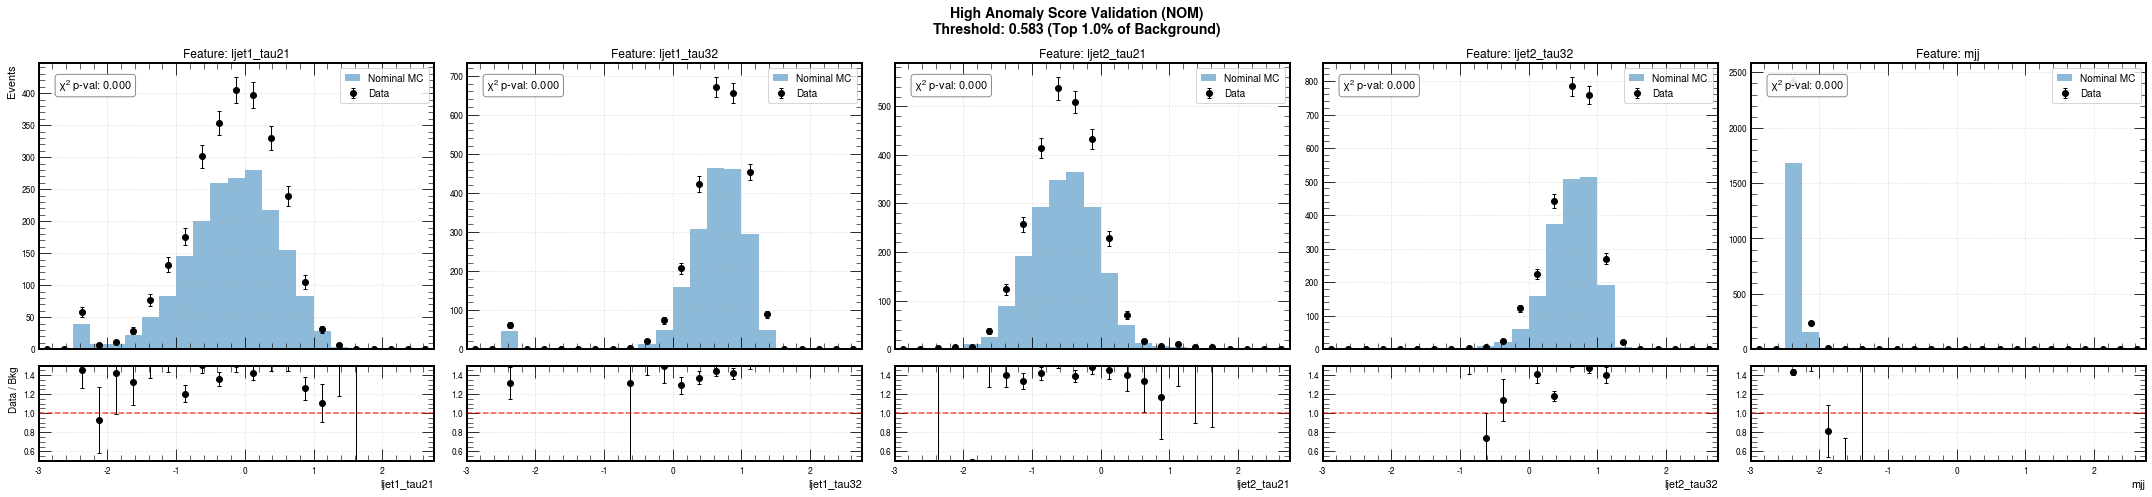

--- Model-Independent Working Point ---
Target Background Efficiency: 1.0%
Calculated Threshold: 0.5481


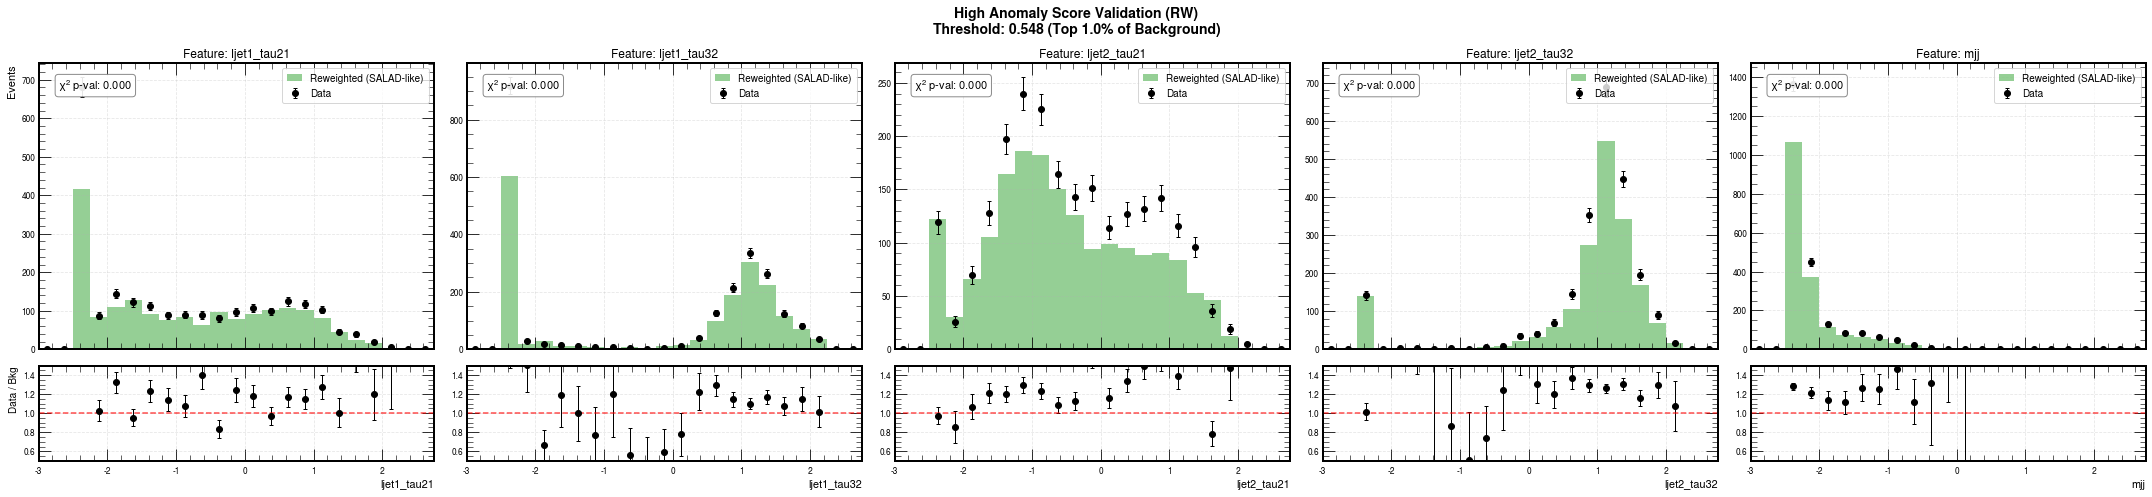

--- Model-Independent Working Point ---
Target Background Efficiency: 1.0%
Calculated Threshold: 0.5548


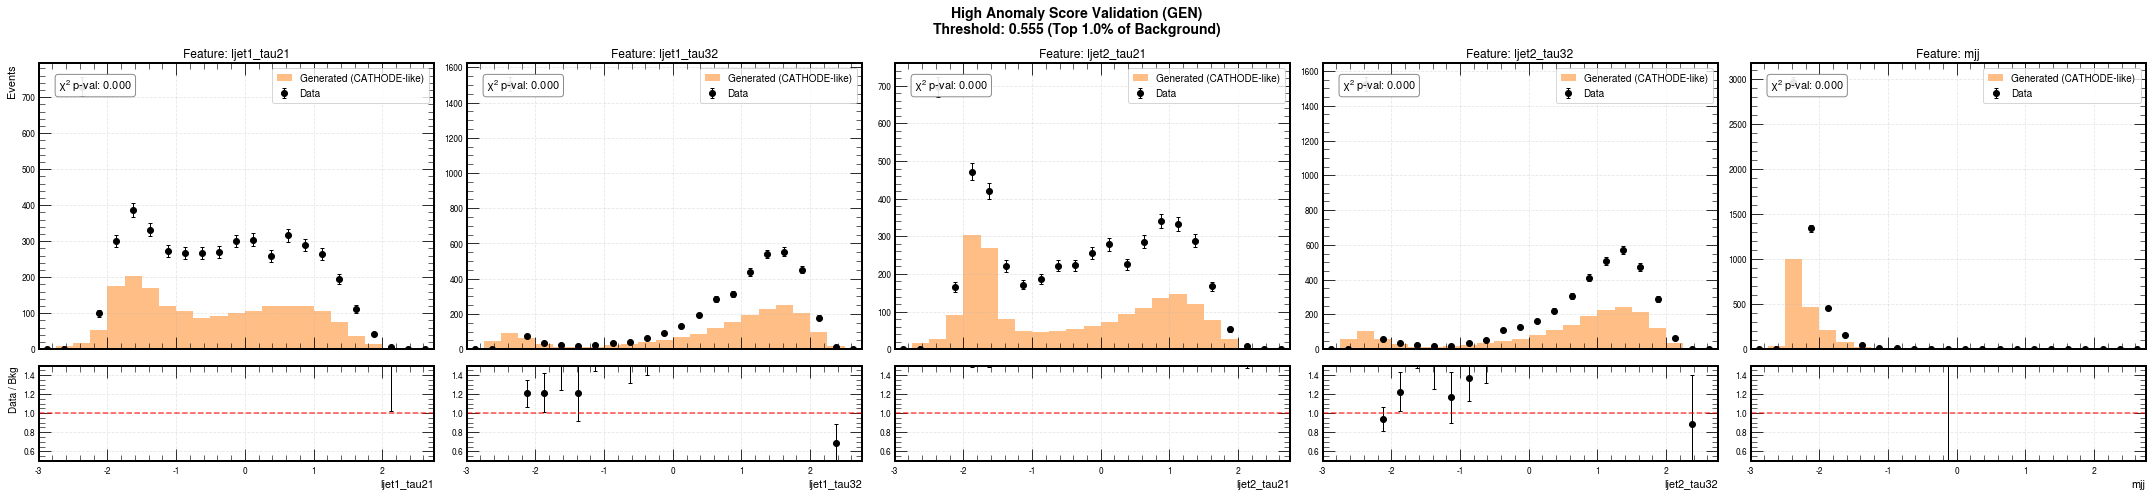

In [25]:
# for feat in features_vars:
bkg_efficiency = 0.01  # 5% background efficiency

nom_cut = plot_sr_closure(df_data, df_mc_rw, bkg_type="NOM", features=features_vars, target_bkg_eff=bkg_efficiency)
rw_cut = plot_sr_closure(df_data, df_mc_rw, bkg_type="RW", features=features_vars, target_bkg_eff=bkg_efficiency)
gen_cut = plot_sr_closure(df_data, df_mc_gen, bkg_type="GEN", features=features_vars, target_bkg_eff=bkg_efficiency)

In [ ]:
def optimize_cut_threshold(df_sig_dict, df_bkg, bkg_type, sig_modes, thres_max):
    """
    df_sig_dict: Dictionary mapping sig_mode strings to their respective DataFrames
    sig_modes: List of strings to plot, e.g., ["500_3", "1000_3", ...]
    """
    if bkg_type == "NOM":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    thresholds = np.linspace(0.001, thres_max, 100)
    num_modes = len(sig_modes)
    
    # 1. Pre-calculate background yields
    b_yields = np.zeros(len(thresholds))
    for idx, thresh in enumerate(thresholds):
        b_mask = df_bkg[bkg_col_score] > thresh
        b_yields[idx] = df_bkg.loc[b_mask, bkg_weight_name].sum()

    # 2. Setup dynamic grid: Max 4 columns per row
    cols = min(4, num_modes)
    rows = math.ceil(num_modes / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows), squeeze=False)
    fig.suptitle(f"Cut Optimization vs {bkg_type} Background", fontsize=16, fontweight='bold', y=1.02)
    
    # Flatten axes array for easy 1D indexing in the loop
    axes_flat = axes.flatten()
    
    results = {}

    # 3. Loop through each signal mode
    for i, sig_mode in enumerate(sig_modes):
        # Extract the dataframe from the dictionary using the sig_mode key
        df_sig = df_sig_dict[sig_mode] 
        
        mass = sig_mode.split("_")[0]
        rinv = f"0.{sig_mode.split('_')[1]}"
        
        s_yields = np.zeros(len(thresholds))
        significances = np.zeros(len(thresholds))
        
        for idx, thresh in enumerate(thresholds):
            s_mask = df_sig[sig_col_score] > thresh
            S = df_sig.loc[s_mask, "final_weight"].sum()
            B = b_yields[idx]
            
            s_yields[idx] = S
            
            if B > 0 and S > 0:
                significances[idx] = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
            else:
                significances[idx] = 0.0

        max_idx = np.argmax(significances)
        max_Z = significances[max_idx]
        opt_thresh = thresholds[max_idx]
        opt_S = s_yields[max_idx]
        opt_B = b_yields[max_idx]
        
        results[sig_mode] = {
            "mass": mass, "rinv": rinv, "opt_thresh": opt_thresh, 
            "max_Z": max_Z, "opt_S": opt_S, "opt_B": opt_B
        }

        # --- Plotting ---
        ax1 = axes_flat[i]
        
        ax1.plot(thresholds, significances, color='purple', lw=2.5, label=r'Expected Sig (Max: %.2f $\sigma$)' % max_Z)
        ax1.axvline(opt_thresh, color='red', linestyle='--', label=f'Opt Cut: < {opt_thresh:.4f}')
        
        ax1.set_xlabel("Anomaly Score Threshold", fontsize=11)
        
        # Only label the left Y-axis on the first column of every row
        if i % cols == 0:
            ax1.set_ylabel("Significance (Asimov Z)", fontsize=12)
            
        ax1.set_title(f"({mass}, {rinv})", fontsize=14, fontweight='bold')
        ax1.legend(loc='upper left', frameon=True)
        ax1.grid(True, linestyle="--", alpha=0.4)
        
        ax2 = ax1.twinx()
        ax2.plot(thresholds, s_yields, color='blue', linestyle=':', alpha=0.7, label='Signal (S)')
        ax2.plot(thresholds, b_yields, color='orange', linestyle=':', alpha=0.7, label='Bkg (B)')
        
        ax2.set_yscale('log')
        
        # Only label the right Y-axis on the last column of every row, or the very last plot
        if (i % cols == cols - 1) or (i == num_modes - 1):
            ax2.set_ylabel("Expected Event Yield", fontsize=12)
            
        ax2.legend(loc='upper right', frameon=True)

    # 4. Hide any unused subplots (if num_modes is not a perfect multiple of 4)
    for j in range(num_modes, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("-" * 55)
    print(f"OPTIMAL CUT SUMMARY vs {bkg_type}")
    print("-" * 55)
    for mode, res in results.items():
        print(f"Signal ({res['mass']}, {res['rinv']}):")
        print(f"  Optimal Threshold : < {res['opt_thresh']:.4f}")
        print(f"  Max Significance  : {res['max_Z']:.2f} sigma")
        print(f"  Expected Signal   : {res['opt_S']:.2f}")
        print(f"  Expected Bkg      : {res['opt_B']:.2f}")
        print("-" * 30)
    
    return results

In [27]:
def optimize_cut_threshold_ver2(df_sig_dict, df_bkg, bkg_type, sig_modes, thres_max):
    if bkg_type == "NOM":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    thresholds = np.linspace(0.001, thres_max, 100)
    num_modes = len(sig_modes)
    
    # 1. Pre-calculate background yields
    b_yields = np.zeros(len(thresholds))
    for idx, thresh in enumerate(thresholds):
        b_mask = df_bkg[bkg_col_score] > thresh
        b_yields[idx] = df_bkg.loc[b_mask, bkg_weight_name].sum()

    # 2. Setup dynamic grid: Max 4 columns per row
    cols = min(4, num_modes)
    rows = math.ceil(num_modes / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows), squeeze=False)
    fig.suptitle(f"Cut Optimization vs {bkg_type} Background", fontsize=16, fontweight='bold', y=1.02)
    
    # Flatten axes array for easy 1D indexing in the loop
    axes_flat = axes.flatten()
    
    results = {}

    # 3. Loop through each signal mode
    for i, sig_mode in enumerate(sig_modes):
        # Extract the dataframe from the dictionary using the sig_mode key
        df_sig = df_sig_dict[sig_mode] 
        
        mass = sig_mode.split("_")[0]
        rinv = f"0.{sig_mode.split('_')[1]}"
        
        s_yields = np.zeros(len(thresholds))
        significances = np.zeros(len(thresholds))
        
        for idx, thresh in enumerate(thresholds):
            s_mask = df_sig[sig_col_score] > thresh
            S = df_sig.loc[s_mask, "final_weight"].sum()
            B = b_yields[idx]
            
            s_yields[idx] = S
            
            # --- INCORPORATED STATISTICAL FLOOR ---
            if B > 0 and S > 0:
                # Enforce a minimum signal and background yield to ensure stable limits
                # and prevent dividing by zero or suffering extreme Poisson fluctuations
                if S < 5.0 or B < 50.0:
                    significances[idx] = 0.0
                else:
                    significances[idx] = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
            else:
                significances[idx] = 0.0
            # ---------------------------------------

        max_idx = np.argmax(significances)
        max_Z = significances[max_idx]
        opt_thresh = thresholds[max_idx]
        opt_S = s_yields[max_idx]
        opt_B = b_yields[max_idx]
        
        results[sig_mode] = {
            "mass": mass, "rinv": rinv, "opt_thresh": opt_thresh, 
            "max_Z": max_Z, "opt_S": opt_S, "opt_B": opt_B
        }

        # --- Plotting ---
        ax1 = axes_flat[i]
        
        ax1.plot(thresholds, significances, color='purple', lw=2.5, label=r'Expected Sig (Max: %.2f $\sigma$)' % max_Z)
        ax1.axvline(opt_thresh, color='red', linestyle='--', label=f'Opt Cut: < {opt_thresh:.4f}')
        
        ax1.set_xlabel("Anomaly Score Threshold", fontsize=11)
        
        # Only label the left Y-axis on the first column of every row
        if i % cols == 0:
            ax1.set_ylabel("Significance (Asimov Z)", fontsize=12)
            
        ax1.set_title(f"({mass}, {rinv})", fontsize=14, fontweight='bold')
        ax1.legend(loc='upper left', frameon=True)
        ax1.grid(True, linestyle="--", alpha=0.4)
        
        ax2 = ax1.twinx()
        ax2.plot(thresholds, s_yields, color='blue', linestyle=':', alpha=0.7, label='Signal (S)')
        ax2.plot(thresholds, b_yields, color='orange', linestyle=':', alpha=0.7, label='Bkg (B)')
        
        ax2.set_yscale('log')
        
        # Only label the right Y-axis on the last column of every row, or the very last plot
        if (i % cols == cols - 1) or (i == num_modes - 1):
            ax2.set_ylabel("Expected Event Yield", fontsize=12)
            
        ax2.legend(loc='upper right', frameon=True)

    # 4. Hide any unused subplots (if num_modes is not a perfect multiple of 4)
    for j in range(num_modes, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("-" * 55)
    print(f"OPTIMAL CUT SUMMARY vs {bkg_type}")
    print("-" * 55)
    for mode, res in results.items():
        print(f"Signal ({res['mass']}, {res['rinv']}):")
        print(f"  Optimal Threshold : < {res['opt_thresh']:.4f}")
        print(f"  Max Significance  : {res['max_Z']:.2f} sigma")
        print(f"  Expected Signal   : {res['opt_S']:.2f}")
        print(f"  Expected Bkg      : {res['opt_B']:.2f}")
        print("-" * 30)
    
    return results

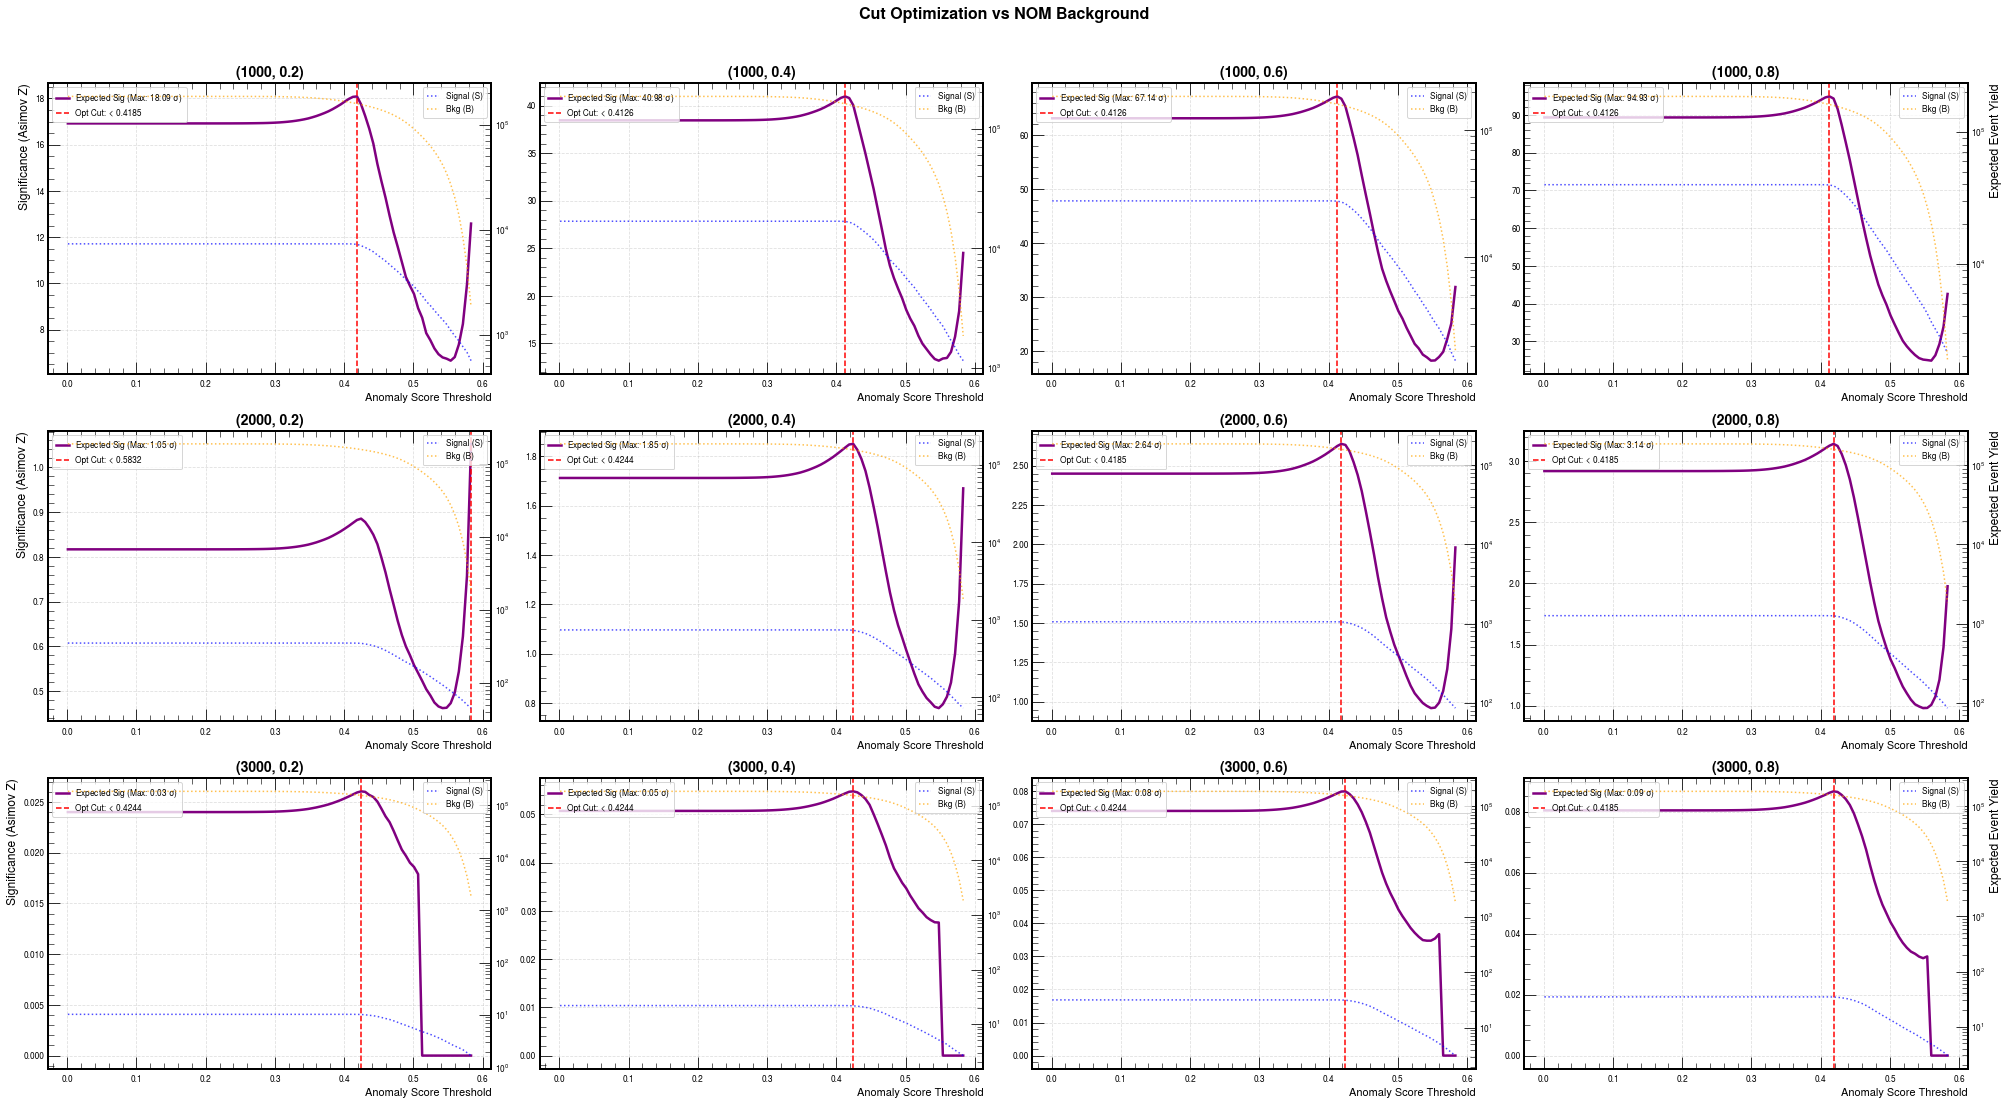

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs NOM
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : < 0.4185
  Max Significance  : 18.09 sigma
  Expected Signal   : 7251.60
  Expected Bkg      : 158315.17
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : < 0.4126
  Max Significance  : 40.98 sigma
  Expected Signal   : 16726.55
  Expected Bkg      : 161125.73
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : < 0.4126
  Max Significance  : 67.14 sigma
  Expected Signal   : 27690.39
  Expected Bkg      : 161125.73
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : < 0.4126
  Max Significance  : 94.93 sigma
  Expected Signal   : 39577.41
  Expected Bkg      : 161125.73
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : < 0.5832
  Max Significance  : 1.05 sigma
  Expected Signal   : 45.46
  Expected Bkg      : 1850.58
----

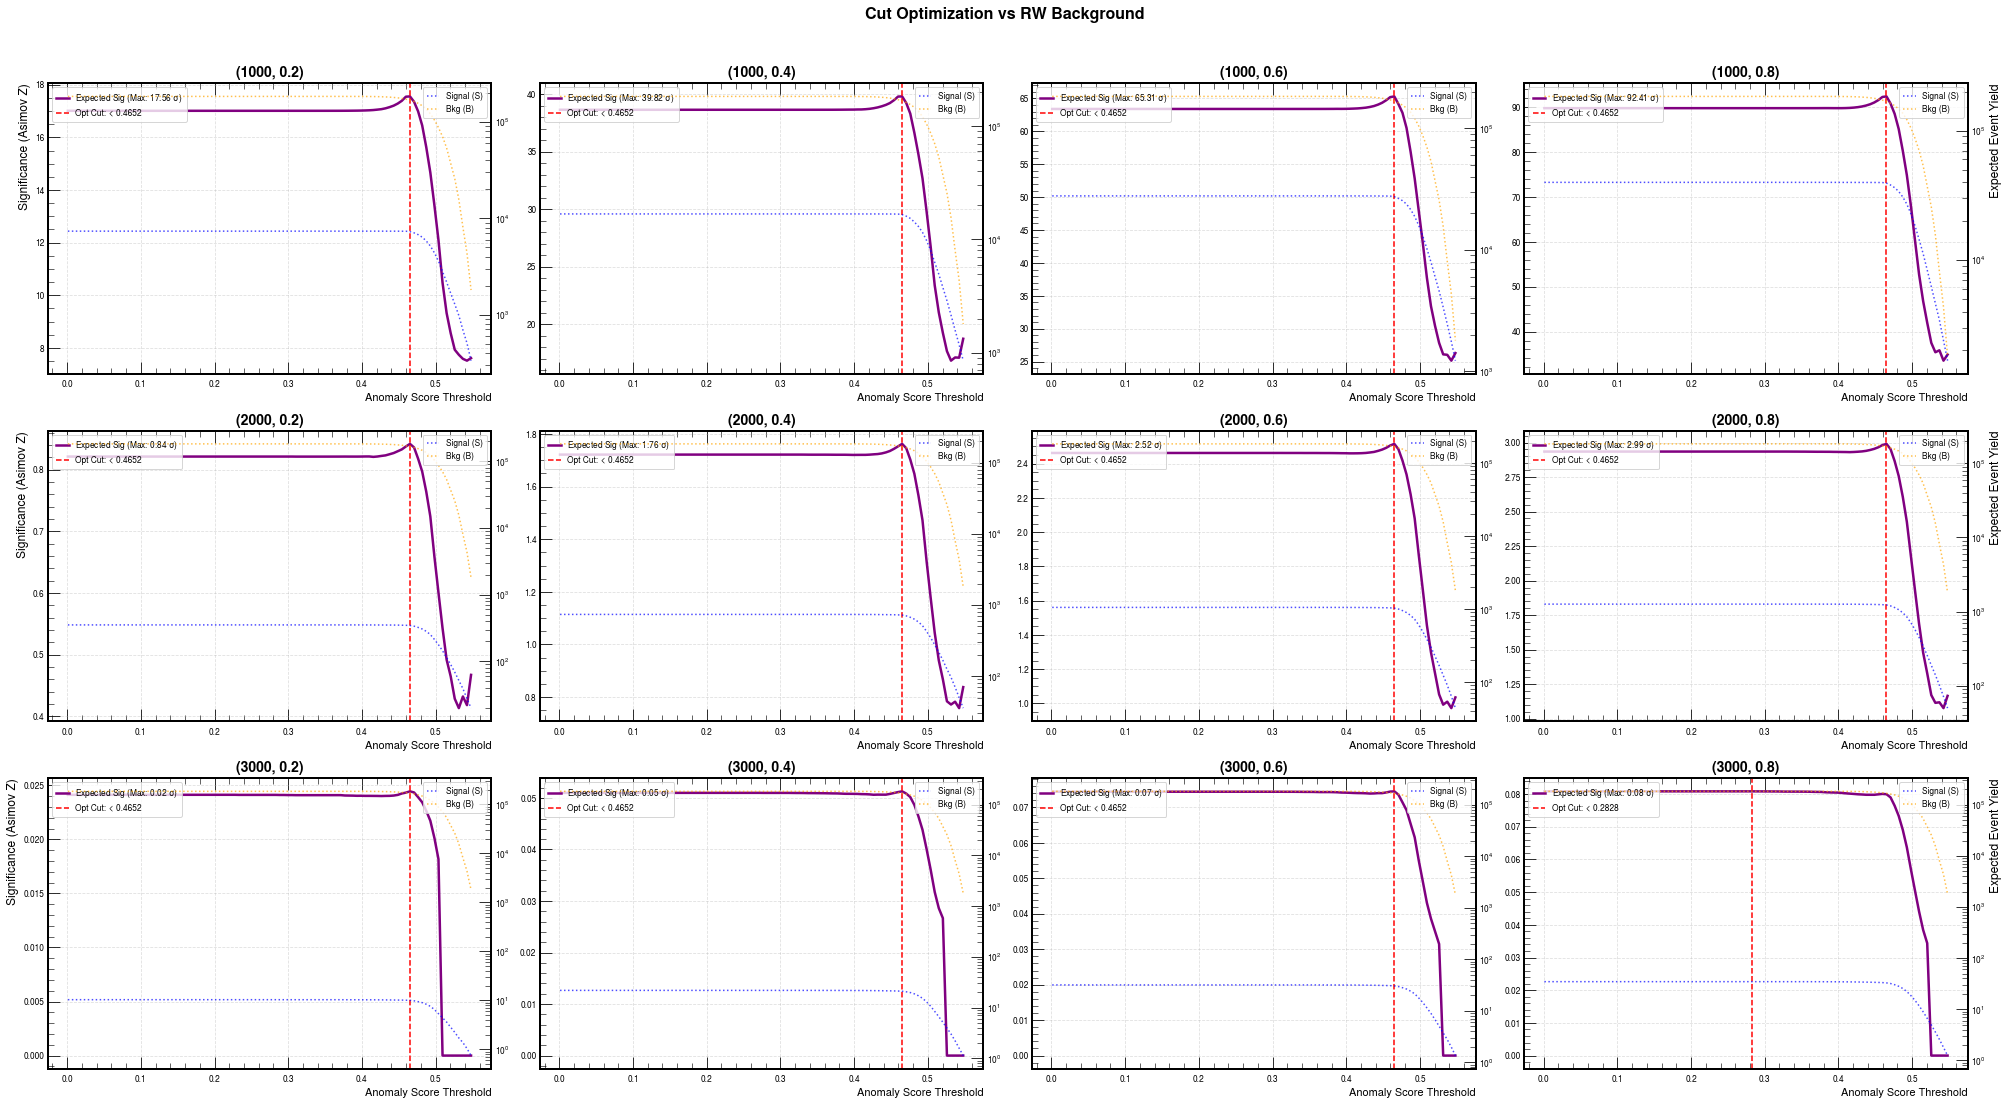

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs RW
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : < 0.4652
  Max Significance  : 17.56 sigma
  Expected Signal   : 7239.48
  Expected Bkg      : 167657.81
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : < 0.4652
  Max Significance  : 39.82 sigma
  Expected Signal   : 16566.72
  Expected Bkg      : 167657.81
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : < 0.4652
  Max Significance  : 65.31 sigma
  Expected Signal   : 27445.49
  Expected Bkg      : 167657.81
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : < 0.4652
  Max Significance  : 92.41 sigma
  Expected Signal   : 39235.45
  Expected Bkg      : 167657.81
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : < 0.4652
  Max Significance  : 0.84 sigma
  Expected Signal   : 344.75
  Expected Bkg      : 167657.81
--

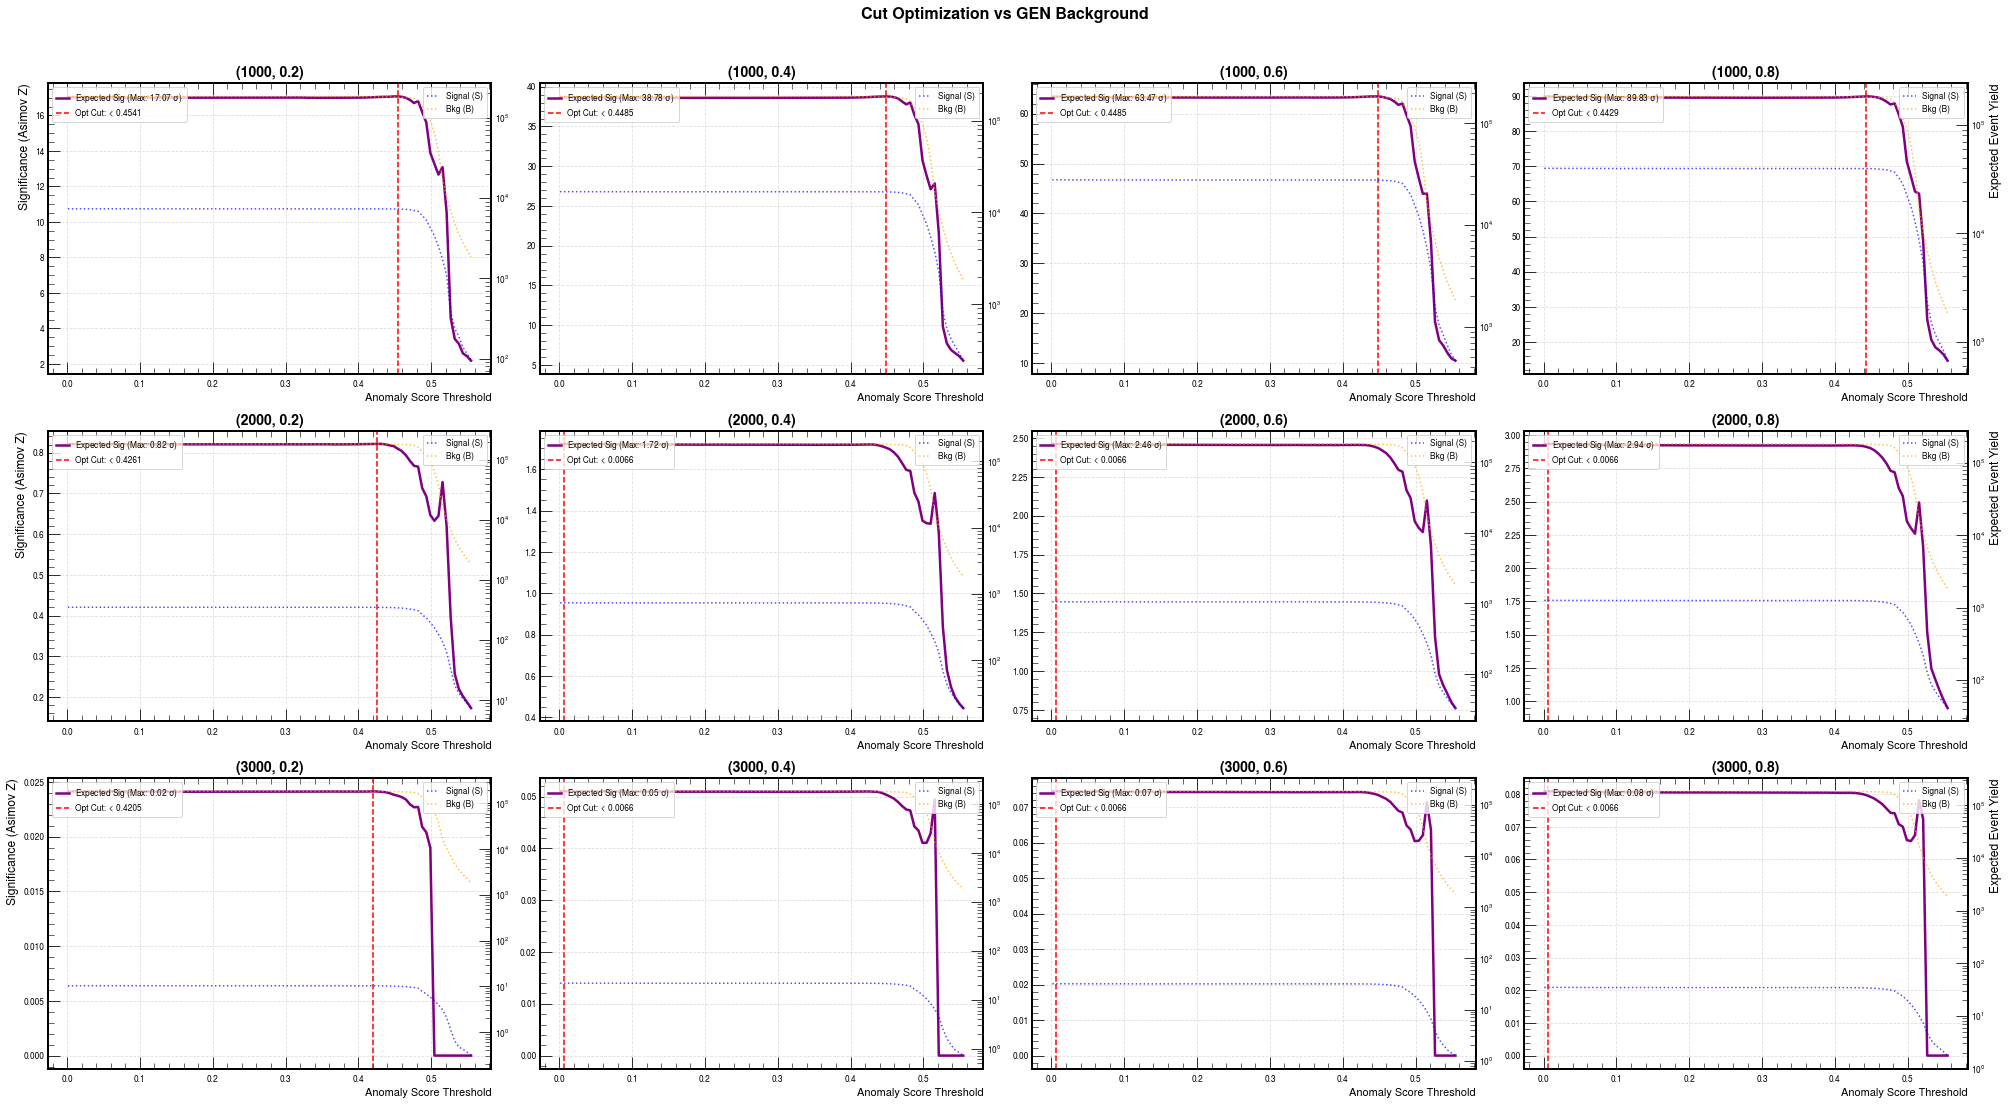

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs GEN
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : < 0.4541
  Max Significance  : 17.07 sigma
  Expected Signal   : 7287.97
  Expected Bkg      : 179892.80
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : < 0.4485
  Max Significance  : 38.78 sigma
  Expected Signal   : 16726.55
  Expected Bkg      : 180515.62
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : < 0.4485
  Max Significance  : 63.47 sigma
  Expected Signal   : 27629.77
  Expected Bkg      : 180515.62
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : < 0.4429
  Max Significance  : 89.83 sigma
  Expected Signal   : 39545.88
  Expected Bkg      : 181039.35
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : < 0.4261
  Max Significance  : 0.82 sigma
  Expected Signal   : 350.80
  Expected Bkg      : 182087.36
-

In [28]:
opt_cut_results = {}
# bkg_type = "RW" # NOM, RW, GEN

for bkg_type in ["NOM", "RW", "GEN"]:
    # for sig_mode in SIGNAL_MODES:
    if bkg_type == "GEN":
        df_mc = df_mc_gen
        max_cut = gen_cut
    elif bkg_type == "RW":
        df_mc = df_mc_rw
        max_cut = rw_cut
    elif bkg_type == "NOM":
        df_mc = df_mc_rw
        max_cut = nom_cut

    opt_cut_results[f"{bkg_type}_{detector_type}"] = optimize_cut_threshold_ver2(df_sig_def, df_mc, bkg_type, SIGNAL_MODES, thres_max=max_cut)


## Phase 1 (No BSM Model)

#### Deviation of Data from Background 

In [21]:
import pyhf
import numpy as np
import scipy.stats

# Optional: Set the pyhf backend to use NumPy for simple CPU execution
pyhf.set_backend("numpy")

def calculate_agnostic_deviation(data_counts, bkg_counts, bkg_stat_unc):
    """
    Calculates the statistical deviation of Data from Background 
    using a model-agnostic generic signal in pyhf.
    """
    
    # 1. Define the Generic Signal (The Data Excess)
    # We cap the minimum at 1e-6 to avoid pyhf errors with absolute zero yields
    generic_signal = [max(d - b, 1e-6) for d, b in zip(data_counts, bkg_counts)]
    
    # If there is absolutely no excess anywhere, return 0 significance
    if sum(generic_signal) <= len(generic_signal) * 1e-6:
        print("No data excess found over background.")
        return 0.5, 0.0, generic_signal

    # 2. Build the pyhf workspace dictionary
    workspace_dict = {
        "channels": [
            {
                "name": "anomaly_region",
                "samples": [
                    {
                        "name": "Generic_Anomaly",
                        "data": generic_signal,
                        "modifiers": [
                            # The signal strength parameter we will test
                            {"name": "mu", "type": "normfactor", "data": None}
                        ]
                    },
                    {
                        "name": "Background",
                        "data": bkg_counts,
                        "modifiers": [
                            # staterror automatically handles independent bin-by-bin 
                            # statistical uncertainties based on your MC weights
                            {
                                "name": "bkg_stat_unc",
                                "type": "staterror",
                                "data": bkg_stat_unc
                            }
                        ]
                    }
                ]
            }
        ],
        "observations": [
            {"name": "anomaly_region", "data": data_counts}
        ],
        "measurements": [
            {"name": "agnostic_test", "config": {"poi": "mu", "mparameters": []}}
        ],
        "version": "1.0.0"
    }

    # 3. Initialize Workspace and Model
    ws = pyhf.Workspace(workspace_dict)
    model = ws.model()
    data = ws.data(model)

    # 4. Perform the Hypothesis Test
    # Testing mu=0 (Background-Only Hypothesis) using the q0 test statistic for discovery
    try:
        result = pyhf.infer.hypotest(
            0.0, data, model, test_stat="q0", return_tail_probs=True
        )
        p0_value = result[1] # result is (CLs_obs, p0_obs) when return_tail_probs=True
    except Exception as e:
        print(f"pyhf fit failed: {e}")
        return None, None, generic_signal

    # 5. Convert p0-value to Gaussian standard deviations (sigma)
    if p0_value < 0.5:
        significance = scipy.stats.norm.isf(p0_value)
    else:
        significance = 0.0

    print("=" * 45)
    print("      MODEL-AGNOSTIC DEVIATION RESULTS     ")
    print("=" * 45)
    print(f"Total Data Events    : {sum(data_counts)}")
    print(f"Total Expected Bkg   : {sum(bkg_counts):.2f}")
    print(f"Integrated Excess    : {sum(generic_signal):.2f}")
    print("-" * 45)
    print(f"Null p0-value        : {p0_value:.4e}")
    print(f"Global Significance  : {significance:.2f} sigma")
    print("=" * 45)

    return p0_value, significance, generic_signal


In [31]:
def get_poisson_errors(counts):
    """
    Returns asymmetric Garwood/Poisson errors (68.27% CL) for an array of counts.
    Returns an array of shape (2, N) for [error_down, error_up].
    """
    alpha = 1 - 0.682689492 # 1-sigma interval
    lower = np.zeros_like(counts, dtype=float)
    upper = np.zeros_like(counts, dtype=float)
    
    # Lower bound is 0 for 0 counts, otherwise calculated via chi2
    mask = counts > 0
    lower[mask] = 0.5 * stats.chi2.ppf(alpha / 2, 2 * counts[mask])
    
    # Upper bound is well-defined for all counts, including 0
    upper = 0.5 * stats.chi2.ppf(1 - alpha / 2, 2 * (counts + 1))
    
    # Matplotlib error bars require relative distances from the central value
    err_down = counts - lower
    err_up = upper - counts
    
    return np.vstack([err_down, err_up])

In [29]:
def plot_all_features_post_cut(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, bkg_type, closure):
    # 1. Apply the cut
    if closure == "HIGH":
        mask_data = df_data[score_col_data] > threshold
        mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    print(f"Data passing cut: {mask_data.sum()}")
    print(f"Bkg passing cut:  {mask_bkg.sum()}")

    # 2. Features mapping
    features = {
        'mjj':           {"bins": np.linspace(0, 4000, 21), "label": "Invariant Mass $m_{jj}$ [GeV]", "log": True, "unit": "GeV"},
        'met_recalc_pt': {"bins": np.linspace(400, 4000, 21), "label": "$E_{T}^{\\mathrm{miss}}$ [GeV]", "log": True, "unit": "GeV"},
        'ht':            {"bins": np.linspace(400, 4000, 21), "label": "$H_T$ [GeV]", "log": True, "unit": "GeV"},
        'ljet1_tau21':   {"bins": np.linspace(0, 1, 21),      "label": "Leading Jet $\\tau_{21}$", "log": False, "unit": None},
        'ljet1_tau32':   {"bins": np.linspace(0, 1, 21),      "label": "Leading Jet $\\tau_{32}$", "log": False, "unit": None},
        'ljet2_tau21':   {"bins": np.linspace(0, 1, 21),      "label": "Subleading Jet $\\tau_{21}$", "log": False, "unit": None},
        'ljet2_tau32':   {"bins": np.linspace(0, 1, 21),      "label": "Subleading Jet $\\tau_{32}$", "log": False, "unit": None}
    }

    fig = plt.figure(figsize=(8*10, 8))
    outer_grid = gridspec.GridSpec(1, 8, wspace=0.3, hspace=0.3)

    for i, (feat, info) in enumerate(features.items()):
        bins = info["bins"]
        bin_width = bins[1] - bins[0]
        
        # Clip data to max/min bin edges (Handle Overflow)
        data_var = np.clip(df_data.loc[mask_data, feat], bins[0], bins[-1])
        bkg_var = np.clip(df_bkg.loc[mask_bkg, feat], bins[0], bins[-1])
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        data_counts, _ = np.histogram(data_var, bins=bins)
        bkg_counts, _  = np.histogram(bkg_var, bins=bins, weights=bkg_weights)
        bkg_var_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights**2)
        

        bkg_stat_unc = np.sqrt(bkg_var_counts)
        data_poisson_err = get_poisson_errors(data_counts) # NEW: Asymmetric data errors

        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], height_ratios=[3, 1], hspace=0.08)
        ax_main = fig.add_subplot(inner_grid[0])
        ax_ratio = fig.add_subplot(inner_grid[1], sharex=ax_main)
        
        # --- Main Plot ---
        hep.histplot(bkg_counts, bins=bins, ax=ax_main, histtype='fill', 
                     color='cornflowerblue', label=f'Expected {bkg_type}', edgecolor='black')
        
        ax_main.stairs(
            values=bkg_counts + bkg_stat_unc, 
            baseline=bkg_counts - bkg_stat_unc, 
            edges=bins, 
            fill=True, hatch='////', color='gray', alpha=0.4, label='Bkg Stat Unc'
        )

        hep.histplot(data_counts, bins=bins, ax=ax_main, histtype='errorbar', 
                     color='black', label='Data', yerr=data_poisson_err) 

        ylabel = f"Events / {bin_width:.2g} {info['unit']}" if info['unit'] else f"Events / {bin_width:.2g}"
        ax_main.set_ylabel(ylabel)
        ax_main.legend(loc='upper right', frameon=False, fontsize=14)
        ax_main.tick_params(labelbottom=False)
        
        if info["log"]:
            ax_main.set_yscale('log')
            ax_main.set_ylim(0.1, max(np.max(data_counts), np.max(bkg_counts)) * 10)
        else:
            ax_main.set_ylim(0, max(np.max(data_counts), np.max(bkg_counts)) * 1.5)
            
        region_text = (
            "SR $E_{T}^{\\mathrm{miss}} > 600$ GeV, $H_T > 600$ GeV\n"
            f"Score {'>' if closure=='HIGH' else '<'} {threshold:.2f}"
        )
        ax_main.text(0.05, 0.95, region_text, transform=ax_main.transAxes, 
                     fontsize=14, verticalalignment='top')

        ratio = np.divide(data_counts, bkg_counts, out=np.ones_like(data_counts, dtype=float), where=(bkg_counts>0))

        ratio_poisson_err = np.zeros_like(data_poisson_err)
        valid_bkg = bkg_counts > 0
        ratio_poisson_err[0, valid_bkg] = data_poisson_err[0, valid_bkg] / bkg_counts[valid_bkg] # Down errors
        ratio_poisson_err[1, valid_bkg] = data_poisson_err[1, valid_bkg] / bkg_counts[valid_bkg] # Up errors
        
        hep.histplot(ratio, bins=bins, ax=ax_ratio, histtype='errorbar', color='black', yerr=ratio_poisson_err)
        
        rel_bkg_unc = np.divide(bkg_stat_unc, bkg_counts, out=np.zeros_like(bkg_stat_unc, dtype=float), where=(bkg_counts>0))
        ax_ratio.stairs(
            values=1 + rel_bkg_unc, 
            baseline=1 - rel_bkg_unc, 
            edges=bins, 
            fill=True, hatch='////', color='gray', alpha=0.4
        )
        
        ax_ratio.axhline(1, color='black', linestyle='--', linewidth=1)
        ax_ratio.set_xlabel(info["label"])
        ax_ratio.set_ylabel("Data / Bkg", fontsize=14)
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.set_yticks([0.5, 0.75, 1.0, 1.25, 1.5])

    plt.tight_layout()
    plt.show()

def plot_coarse_major_blocks(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, closure):
    # 1. Apply the ML Filter
    if closure == "HIGH":
            mask_data = df_data[score_col_data] > threshold
            mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    # 2. Define the EXACT coarse bin edges for each feature
    features = {
        'mjj': {
            'bins': np.array([400, 1000, 2000, 3000, 4000]), 
            'log': True, 
            'title': 'Invariant Mass $m_{jj}$ [GeV]'
        },
        'ljet1_tau21': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Leading Jet $\\tau_{21}$'
        },
        'ljet1_tau32': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Leading Jet $\\tau_{32}$'
        },
        'ljet2_tau21': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Subleading Jet $\\tau_{21}$'
        },
        'ljet2_tau32': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Subleading Jet $\\tau_{32}$'
        }
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (feat, info) in enumerate(features.items()):
        ax = axes[i]
        bins = info['bins']
        
        # Extract filtered feature arrays
        data_var = df_data.loc[mask_data, feat]
        bkg_var = df_bkg.loc[mask_bkg, feat]
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        # Calculate histograms using the DIRECT coarse bin edges
        data_counts, _ = np.histogram(data_var, bins=bins)
        bkg_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights)
        bkg_var_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights**2)
        bkg_stat_unc = np.sqrt(bkg_var_counts)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        bin_widths = np.diff(bins)
        
        # 1. Plot Expected Background as wide blocks matching coarse bin widths
        ax.bar(bin_centers, bkg_counts, width=bin_widths, color='cornflowerblue', 
               alpha=0.7, edgecolor='navy', label='Expected Bkg')
        
        # 2. Background MC Uncertainty band
        ax.bar(bin_centers, 2 * bkg_stat_unc, width=bin_widths, bottom=bkg_counts - bkg_stat_unc, 
               alpha=0.3, color='gray', hatch='////', label='MC Stat. Unc.')
        
        # 3. Plot Data as points centered inside each coarse bin block
        ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), 
                    fmt='ko', label='Observed Data', capsize=0, elinewidth=1.5, markersize=5)
        
        # Set explicit tick marks on the axis showing exact bin boundaries
        ax.set_xticks(bins)
        
        ax.set_title(info['title'], fontsize=12, fontweight='bold')
        ax.set_ylabel("Events / Bin")
        
        # Y-axis scaling
        if info['log']:
            ax.set_yscale('log')
            max_y = max(np.max(data_counts), np.max(bkg_counts)) * 10
            min_y = max(0.1, np.min(bkg_counts[bkg_counts > 0]) * 0.5) if len(bkg_counts[bkg_counts > 0]) > 0 else 0.1
            ax.set_ylim(min_y, max_y)
        else:
            max_y = max(np.max(data_counts), np.max(bkg_counts)) * 1.3
            ax.set_ylim(0, max_y)
            
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.4)

    # Hide the 6th empty subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

def visualize_5d_major_blocks(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, closure):
    # 1. Apply the ML Filter
    if closure == "HIGH":
            mask_data = df_data[score_col_data] > threshold
            mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    # 2. Define the features and their major block boundaries (the coarse bins)
    features = {
        'mjj': {
            'edges': [400, 1000, 2000, 3000, 4000], 
            'plot_range': (400, 4000), 'log': True, 'title': 'Invariant Mass $m_{jj}$',
            'bins': np.arange(0, 4200, 200)
        },
        'ljet1_tau21': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Leading Jet $\\tau_{21}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet1_tau32': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Leading Jet $\\tau_{32}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet2_tau21': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Subleading Jet $\\tau_{21}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet2_tau32': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Subleading Jet $\\tau_{32}$',
            'bins': np.arange(0, 1.25, 0.25)
        }
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (feat, info) in enumerate(features.items()):
        ax = axes[i]
        
        # We use fine binning just for the visual background/data shapes
        fine_bins = info['bins']
        
        # Extract data
        data_var = df_data.loc[mask_data, feat]
        bkg_var = df_bkg.loc[mask_bkg, feat]
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        # Plot Expected Background
        ax.hist(bkg_var, bins=fine_bins, weights=bkg_weights, 
                color='cornflowerblue', alpha=0.7, label='Expected Bkg')
        
        # Plot Observed Data
        data_counts, _ = np.histogram(data_var, bins=fine_bins)
        bin_centers = (fine_bins[:-1] + fine_bins[1:]) / 2
        ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), 
                    fmt='ko', label='Observed Data', markersize=4)
        
        # Overlay the Major Block Bin Boundaries
        for edge in info['edges']:
            ax.axvline(edge, color='red', linestyle='--', linewidth=2, alpha=0.8)
            
        ax.set_title(info['title'], fontsize=12, fontweight='bold')
        ax.set_ylabel("Events")
        if info['log']:
            ax.set_yscale('log')
        ax.legend()

    # Hide the 6th empty subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

Data passing cut: 5014
Bkg passing cut:  65939


/tmp/ipykernel_655970/1805124053.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


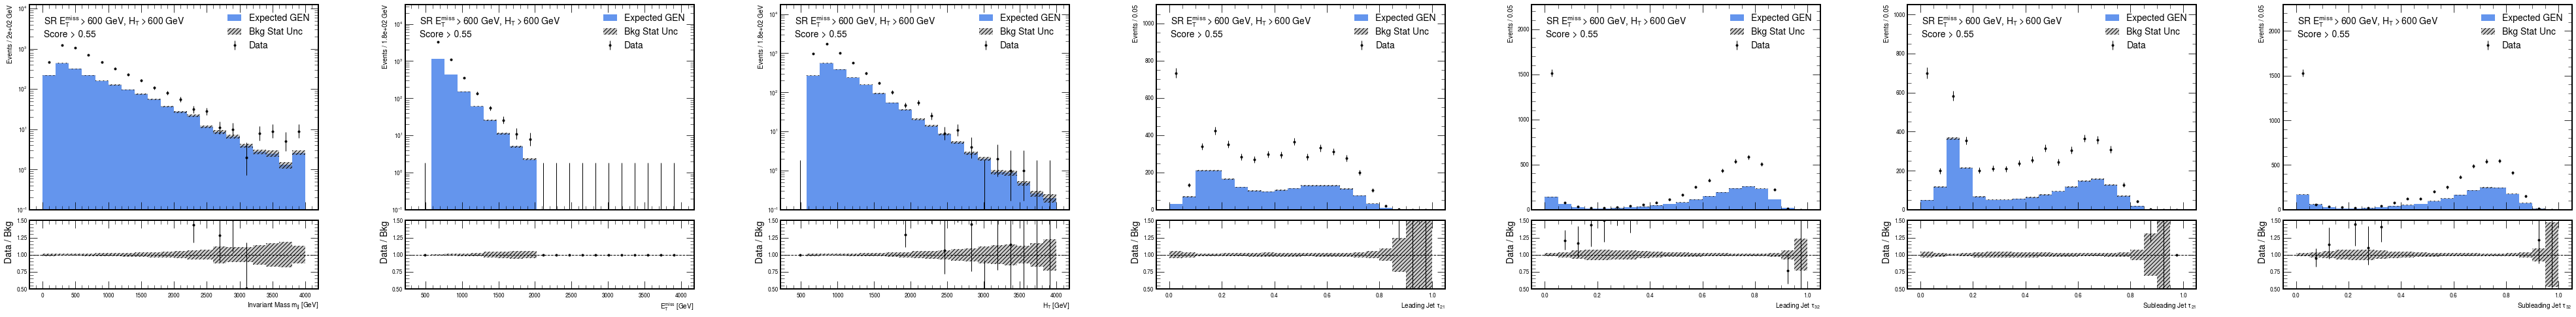

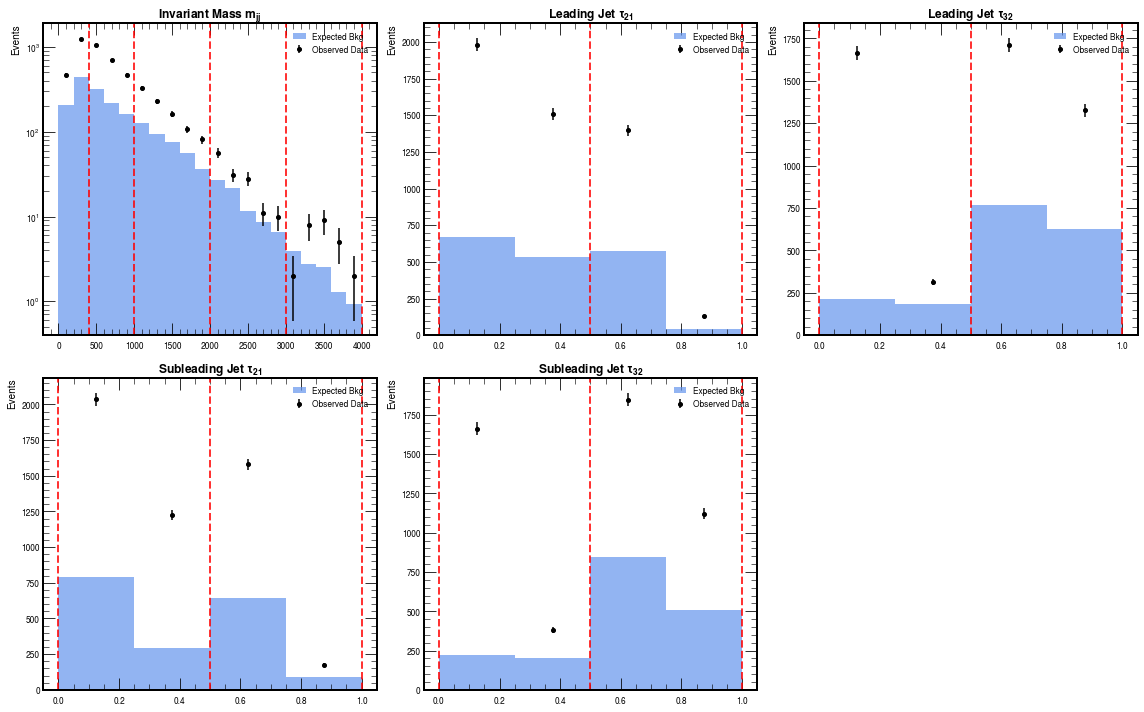

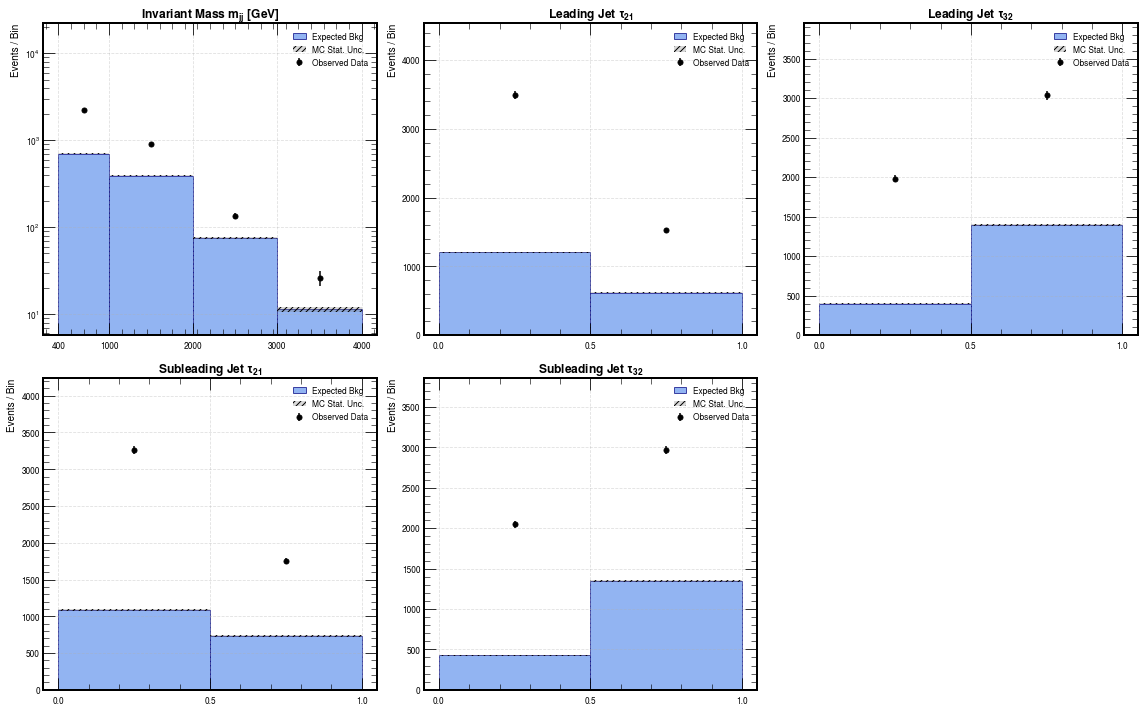

In [33]:
bkg_type = "GEN"
closure = "HIGH"
if bkg_type == "NOM":
    data_col_score = "score_vs_nominal"
    bkg_col_score = "score_vs_data"
    sig_col_score = "bsm_score_Nom"
    bkg_weight_name = "final_weight"
    anomaly_threshold = nom_cut
    df_bkg = df_mc_rw
elif bkg_type == "RW":
    data_col_score = "score_vs_reweighted"
    bkg_col_score = "score_vs_reweighted_data"
    sig_col_score = "bsm_score_Reweight_Median"
    bkg_weight_name = "rw_mediam_weights"
    anomaly_threshold = rw_cut
    df_bkg = df_mc_rw
elif bkg_type == "GEN":
    data_col_score = "score_vs_generate"
    bkg_col_score = "score_vs_data"
    sig_col_score = "bsm_score_Generate_Combined"
    bkg_weight_name = "total_weight"
    anomaly_threshold = gen_cut
    df_bkg = df_mc_gen
else:
    raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")


df_data_unscaled = transform(df_data, scale=False)
df_bkg_unscaled = transform(df_bkg, scale=False)


plot_all_features_post_cut(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    bkg_type=bkg_type,
    closure = closure
)

visualize_5d_major_blocks(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    closure = closure
)

plot_coarse_major_blocks(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    closure = closure
)



# # 3. Run the Agnostic Deviation Test
# p0, sigma, gen_sig = calculate_agnostic_deviation(
#     data_counts=data_counts_list, 
#     bkg_counts=bkg_counts_list, 
#     bkg_stat_unc=bkg_stat_unc_list
# )

In [34]:
import pyhf
import numpy as np
import pandas as pd
import operator
import warnings

def find_limit_1d(mu_scan, cls_values, threshold=0.05):
    """Interpolates the mu value where CLs crosses 0.05."""
    valid = ~np.isnan(cls_values)
    if np.sum(valid) < 2:
        return np.nan
        
    m = np.array(mu_scan)[valid]
    c = np.array(cls_values)[valid]
    
    # If the limit never crossed 0.05, return NaN instead of a false 10.0
    if np.min(c) > threshold:
        return np.nan
        
    idx = np.argsort(c)
    return np.interp(threshold, c[idx], m[idx])

def calculate_pyhf_limits(
    df_sig_dict, 
    signal_modes, 
    df_mc, 
    df_data, 
    bkg_type, 
    score_cuts, 
    df_meta,
    mjj_bins, 
    mjj_col="mjj",
    bkg_syst_frac=0.10, 
    lumi_unc_frac=0.017, 
    cut_direction="greater"
):
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    pyhf.set_backend("numpy")
    
    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
        apply_lumi_to_bkg = True 
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
        apply_lumi_to_bkg = False 
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
        apply_lumi_to_bkg = False 
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    op = operator.gt if cut_direction == "greater" else operator.lt
    results = []

    print(f"--- Running Shape Analysis pyhf Limits for Background: {bkg_type} ---")
    
    for sig_mode in signal_modes:
        df_sig = df_sig_dict[sig_mode]
        mass = int(sig_mode.split("_")[0])
        rinv_val = int(sig_mode.split("_")[1])
        meta_row = df_meta[(df_meta['Mass'] == mass) & (df_meta['Rinv'] == rinv_val)]
        
        if meta_row.empty:
            continue
            
        xs_nom = meta_row.iloc[0]['XS']
        theory_unc = meta_row.iloc[0]['TheoryUnc']
        
        if isinstance(score_cuts, dict):
            cut = score_cuts.get(sig_mode)
            if isinstance(cut, dict): 
                cut = cut.get('opt_thresh', score_cuts.get(sig_mode))
        else:
            cut = float(score_cuts)

        pass_sig = df_sig[op(df_sig[sig_col_score], cut)].copy()
        pass_bkg = df_mc[op(df_mc[bkg_col_score], cut)].copy()
        pass_data = df_data[op(df_data[data_col_score], cut)].copy()
        
        if len(pass_sig) == 0 or len(pass_bkg) == 0:
            print(f"  [{sig_mode}] Zero events passed cut. Skipping.")
            continue
            
        pass_sig_unscaled = transform(pass_sig, scale=False)
        pass_bkg_unscaled = transform(pass_bkg, scale=False)
        pass_data_unscaled = transform(pass_data, scale=False)
        
        sig_mjj = pass_sig_unscaled[mjj_col].to_numpy()
        sig_w   = pass_sig_unscaled["final_weight"].to_numpy()
        bkg_mjj = pass_bkg_unscaled[mjj_col].to_numpy()
        bkg_w   = pass_bkg_unscaled[bkg_weight_name].to_numpy()
        data_mjj = pass_data_unscaled[mjj_col].to_numpy()
        
        hist_sig, _ = np.histogram(sig_mjj, bins=mjj_bins, weights=sig_w)
        hist_bkg, _ = np.histogram(bkg_mjj, bins=mjj_bins, weights=bkg_w)
        hist_data, _ = np.histogram(data_mjj, bins=mjj_bins)
        hist_bkg_var, _ = np.histogram(bkg_mjj, bins=mjj_bins, weights=bkg_w**2)

        total_s = np.sum(hist_sig)
        total_b = np.sum(hist_bkg)
        total_d = np.sum(hist_data)

        if total_s <= 0:
            print(f"  [{sig_mode}] Signal yield <= 0. Skipping.")
            continue
            
        # ---------------------------------------------------------
        # FIX 1: STABILIZE BINS
        # Force a baseline physics floor (1e-4) so the optimizer 
        # gradient never divides by zero if Data > 0 in an empty bin.
        # ---------------------------------------------------------
        epsilon = 1e-4
        hist_bkg_safe = np.maximum(hist_bkg, epsilon)
        hist_bkg_var_safe = np.maximum(hist_bkg_var, epsilon)
        hist_sig_safe = np.clip(hist_sig, 0.0, None) 

        bkg_modifiers = [
            {"name": "stat_uncert", "type": "staterror", "data": np.sqrt(hist_bkg_var_safe).tolist()},
            {"name": "bkg_syst", "type": "normsys", "data": {"hi": 1.0 + bkg_syst_frac, "lo": max(1.0 - bkg_syst_frac, 0.001)}}
        ]
        
        sig_modifiers = [
            {"name": "mu", "type": "normfactor", "data": None},
            {"name": "sig_theory_unc", "type": "normsys", "data": {"hi": 1.0 + theory_unc, "lo": max(1.0 - theory_unc, 0.001)}}
        ]
        
        if apply_lumi_to_bkg:
            bkg_modifiers.append({"name": "lumi_unc", "type": "normsys", "data": {"hi": 1.0 + lumi_unc_frac, "lo": max(1.0 - lumi_unc_frac, 0.001)}})
            sig_modifiers.append({"name": "lumi_unc", "type": "normsys", "data": {"hi": 1.0 + lumi_unc_frac, "lo": max(1.0 - lumi_unc_frac, 0.001)}})
        else:
            sig_modifiers.append({"name": "lumi_unc", "type": "normsys", "data": {"hi": 1.0 + lumi_unc_frac, "lo": max(1.0 - lumi_unc_frac, 0.001)}})

        # ---------------------------------------------------------
        # FIX 2: DYNAMIC MU MAX
        # Calculate exactly how high the data pushes the observed mu,
        # then set the scan maximum appropriately.
        # ---------------------------------------------------------
        approx_mu_exp = 2.0 * np.sqrt(total_b + 1.0) / max(total_s, 1e-5)
        approx_mu_obs = max(total_d - total_b, 0.0) / max(total_s, 1e-5)
        
        # Max of: 10, the expected limit * 10, or the observed excess * 5
        mu_max = max(10.0, approx_mu_exp * 10.0, approx_mu_obs * 5.0)
        mu_max = min(mu_max, 500000.0) # Hard safety cap
        
        spec = {
            "channels": [{"name": "SR_mjj", "samples": [
                {
                    "name": "signal", 
                    "data": hist_sig_safe.tolist(),
                    "modifiers": sig_modifiers
                },
                {
                    "name": "background", 
                    "data": hist_bkg_safe.tolist(), 
                    "modifiers": bkg_modifiers
                }
            ]}],
            "observations": [{"name": "SR_mjj", "data": hist_data.tolist()}],
            "measurements": [
                {
                    "name": "Measurement", 
                    "config": {
                        "poi": "mu", 
                        "parameters": [{"name": "mu", "bounds": [[0.0, mu_max * 1.5]]}]
                    }
                }
            ],
            "version": "1.0.0"
        }

        workspace = pyhf.Workspace(spec)
        model = workspace.model()
        data_ws = workspace.data(model)

        # We use geomspace to densely sample small numbers while still reaching the huge ones
        mu_scan = np.geomspace(0.01, mu_max, 60)
        obs_cls_list, exp_cls_list = [], []
        
        for mu_val in mu_scan:
            try:
                obs, exp = pyhf.infer.hypotest(
                    float(mu_val), data_ws, model, test_stat="qtilde", return_expected_set=True
                )
                obs_cls_list.append(float(obs))
                exp_cls_list.append([float(e) for e in exp])
            except Exception:
                # Silently catch optimizer instability at extreme values
                obs_cls_list.append(np.nan)
                exp_cls_list.append([np.nan]*5)
                
        obs_cls = np.array(obs_cls_list)
        exp_cls_set = np.array(exp_cls_list).T

        obs_limit = find_limit_1d(mu_scan, obs_cls)
        exp_m2    = find_limit_1d(mu_scan, exp_cls_set[0])
        exp_m1    = find_limit_1d(mu_scan, exp_cls_set[1])
        exp_limit = find_limit_1d(mu_scan, exp_cls_set[2])
        exp_p1    = find_limit_1d(mu_scan, exp_cls_set[3])
        exp_p2    = find_limit_1d(mu_scan, exp_cls_set[4])
        
        results.append({
            "Mass": mass, "Rinv": rinv_val, "Cut": cut,
            "Obs_Limit_XS": obs_limit * xs_nom if not np.isnan(obs_limit) else np.nan,
            "Exp_Limit_XS": exp_limit * xs_nom if not np.isnan(exp_limit) else np.nan,
            "Exp_m2_XS": exp_m2 * xs_nom if not np.isnan(exp_m2) else np.nan,
            "Exp_m1_XS": exp_m1 * xs_nom if not np.isnan(exp_m1) else np.nan,
            "Exp_p1_XS": exp_p1 * xs_nom if not np.isnan(exp_p1) else np.nan,
            "Exp_p2_XS": exp_p2 * xs_nom if not np.isnan(exp_p2) else np.nan,
            "S_yield": total_s, "B_yield": total_b, "D_yield": total_d
        })
        
        print(f"  [{sig_mode}] Exp Limit (mu): {exp_limit:.4f}  |  Obs Limit (mu): {obs_limit:.4f}")

    return pd.DataFrame(results)

In [35]:
from scipy.interpolate import griddata
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_2d_brazilian(df_limits, df_meta, bkg_type):
    """
    Generates a publication-quality 2D Brazilian exclusion plot (Mass vs Rinv).
    Draws contours where the signal strength upper limit = 1.0.
    """
    hep.style.use(hep.style.ROOT) 
    
    # Merge limits with metadata to access Theory XS
    df_plot = pd.merge(df_limits, df_meta, on=["Mass", "Rinv"])
    
    # Calculate Signal Strength (mu). If mu <= 1.0, the region is excluded.
    for col in ['Obs_Limit_XS', 'Exp_Limit_XS', 'Exp_m2_XS', 'Exp_m1_XS', 'Exp_p1_XS', 'Exp_p2_XS']:
        new_col = col.replace('_XS', '_mu')
        df_plot[new_col] = df_plot[col] / df_plot['XS']
        
    # Convert Rinv to physical decimal values (e.g., 2 -> 0.2) for standard HEP plotting
    df_plot['Rinv_dec'] = df_plot['Rinv'] / 10.0
    
    # Create a dense grid for smooth contours
    xi = np.linspace(df_plot['Mass'].min(), df_plot['Mass'].max(), 300)
    yi = np.linspace(df_plot['Rinv_dec'].min(), df_plot['Rinv_dec'].max(), 300)
    X, Y = np.meshgrid(xi, yi)
    
    points = (df_plot['Mass'].values, df_plot['Rinv_dec'].values)
    
    # Interpolate mu values onto the dense grid
    # method='cubic' generates smooth continuous curves standard in HEP
    try:
        Z_exp = griddata(points, df_plot['Exp_Limit_mu'].values, (X, Y), method='cubic')
        Z_obs = griddata(points, df_plot['Obs_Limit_mu'].values, (X, Y), method='cubic')
        Z_m1  = griddata(points, df_plot['Exp_m1_mu'].values, (X, Y), method='cubic')
        Z_p1  = griddata(points, df_plot['Exp_p1_mu'].values, (X, Y), method='cubic')
        Z_m2  = griddata(points, df_plot['Exp_m2_mu'].values, (X, Y), method='cubic')
        Z_p2  = griddata(points, df_plot['Exp_p2_mu'].values, (X, Y), method='cubic')
    except Exception:
        # Fallback to linear if cubic geometry fails (due to sparse points)
        Z_exp = griddata(points, df_plot['Exp_Limit_mu'].values, (X, Y), method='linear')
        Z_obs = griddata(points, df_plot['Obs_Limit_mu'].values, (X, Y), method='linear')
        Z_m1  = griddata(points, df_plot['Exp_m1_mu'].values, (X, Y), method='linear')
        Z_p1  = griddata(points, df_plot['Exp_p1_mu'].values, (X, Y), method='linear')
        Z_m2  = griddata(points, df_plot['Exp_m2_mu'].values, (X, Y), method='linear')
        Z_p2  = griddata(points, df_plot['Exp_p2_mu'].values, (X, Y), method='linear')

    # Create categorical map for the uncertainty bands
    # A point is inside the 2-sigma band if its limit could cross 1.0 within +/- 2 sigma.
    # Ergo: (Z_m2 <= 1.0) AND (Z_p2 >= 1.0)
    C = np.zeros_like(Z_exp)
    C[(Z_m2 <= 1.0) & (Z_p2 >= 1.0)] = 1
    C[(Z_m1 <= 1.0) & (Z_p1 >= 1.0)] = 2
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. Plot the Green and Yellow bands
    ax.contourf(X, Y, C, levels=[0.5, 1.5, 2.5], colors=['#FDC536', '#4AD928'], alpha=0.9)
    
    # 2. Draw the primary exclusion boundary lines where limit == 1.0
    ax.contour(X, Y, Z_exp, levels=[1.0], colors='black', linestyles='dashed', linewidths=3)
    ax.contour(X, Y, Z_obs, levels=[1.0], colors='red', linestyles='solid', linewidths=3)
    
    # 3. Add a faint red wash over the actual excluded region (where observed mu < 1.0)
    ax.contourf(X, Y, Z_obs, levels=[0.0, 1.0], colors=['red'], alpha=0.1)
    
    # Plot the original signal mass points as reference markers
    ax.scatter(df_plot['Mass'], df_plot['Rinv_dec'], color='black', marker='o', s=30, zorder=5)
    
    # Custom Legend
    legend_elements = [
        Line2D([0], [0], color='red', lw=3, label='Observed (95% CL)'),
        Line2D([0], [0], color='black', lw=3, linestyle='dashed', label='Expected (95% CL)'),
        Patch(facecolor='#4AD928', edgecolor='none', label=r'Expected $\pm 1\sigma$'),
        Patch(facecolor='#FDC536', edgecolor='none', label=r'Expected $\pm 2\sigma$')
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=12)
    
    # Axis formatting
    ax.set_xlabel(r'$M_{\phi}$ [GeV]', fontsize=16)
    ax.set_ylabel(r'$R_{\text{inv}}$', fontsize=16)
    ax.set_xlim(df_plot['Mass'].min(), df_plot['Mass'].max())
    ax.set_ylim(df_plot['Rinv_dec'].min(), df_plot['Rinv_dec'].max())
    
    # Standard HEP Labeling
    # hep.atlas.text("Internal", ax=ax)
    # hep.atlas.label(data=True, lumi=25.4, ax=ax, loc=0)
    hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)
    ax.text(0.05, 0.70, f"BSM Signal Exclusions\nBackground Est: {bkg_type}", 
            transform=ax.transAxes, fontsize=14, 
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    plt.tight_layout()
    plt.show()

In [36]:
MJJ_BINS = np.arange(0, 5200, 200) 

df_limits_gen = calculate_pyhf_limits(
    df_sig_dict=df_sig_def, 
    signal_modes=SIGNAL_MODES, 
    df_mc=df_mc_gen, 
    df_data=df_data, 
    bkg_type="GEN", 
    score_cuts=opt_cut_results["GEN_default"], 
    df_meta=DF_META,
    mjj_bins=MJJ_BINS, # <-- Added here
    bkg_syst_frac=0.10, 
    cut_direction="greater" # Or "greater" based on your classifier
)

--- Running Shape Analysis pyhf Limits for Background: GEN ---


  [1000_2] Exp Limit (mu): 0.1838  |  Obs Limit (mu): 0.5467
  [1000_4] Exp Limit (mu): 0.0910  |  Obs Limit (mu): 0.2394
  [1000_6] Exp Limit (mu): 0.0606  |  Obs Limit (mu): 0.1517
  [1000_8] Exp Limit (mu): 0.0437  |  Obs Limit (mu): 0.0975
  [2000_2] Exp Limit (mu): 1.5592  |  Obs Limit (mu): 0.6659
  [2000_4] Exp Limit (mu): 0.8285  |  Obs Limit (mu): 0.3113
  [2000_6] Exp Limit (mu): 0.6165  |  Obs Limit (mu): 0.2273
  [2000_8] Exp Limit (mu): 0.5446  |  Obs Limit (mu): 0.2047
  [3000_2] Exp Limit (mu): 36.3659  |  Obs Limit (mu): 14.7836
  [3000_4] Exp Limit (mu): 18.4595  |  Obs Limit (mu): 5.7059
  [3000_6] Exp Limit (mu): 13.0035  |  Obs Limit (mu): 3.9369
  [3000_8] Exp Limit (mu): 11.2443  |  Obs Limit (mu): 3.1744


/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)
/home/aegis/.local/lib/python3.10/site-packages/mplhep/exp_atlas.py:65: FutureWarning: kwarg `label` in function `exp_label()` is deprecated and will be removed: Use `text="..."` instead.
  return label_base.exp_label(**kwargs)


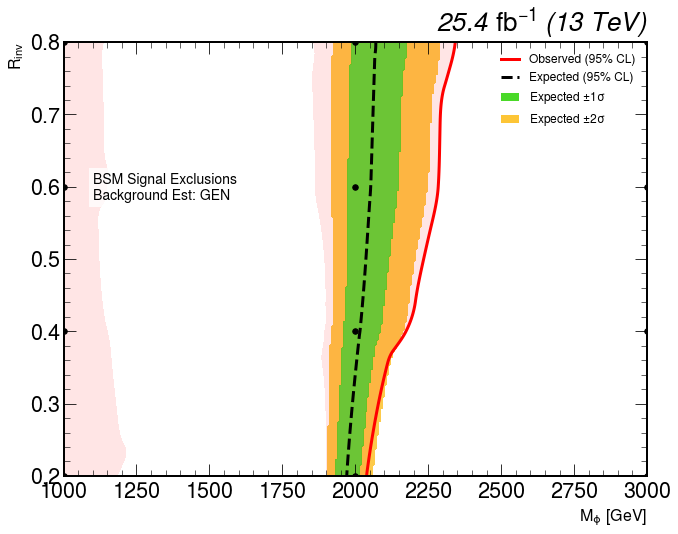

In [37]:
plot_2d_brazilian(df_limits_gen, DF_META, bkg_type="GEN")

--- Running Shape Analysis pyhf Limits for Background: RW ---
  [1000_2] Exp Limit (mu): 0.2489  |  Obs Limit (mu): 0.0569
  [1000_4] Exp Limit (mu): 0.1229  |  Obs Limit (mu): 0.0268
  [1000_6] Exp Limit (mu): 0.0809  |  Obs Limit (mu): 0.0185
  [1000_8] Exp Limit (mu): 0.0579  |  Obs Limit (mu): 0.0138
  [2000_2] Exp Limit (mu): 2.0605  |  Obs Limit (mu): 1.4272
  [2000_4] Exp Limit (mu): 1.0609  |  Obs Limit (mu): 0.7810
  [2000_6] Exp Limit (mu): 0.7948  |  Obs Limit (mu): 0.6393
  [2000_8] Exp Limit (mu): 0.6937  |  Obs Limit (mu): 0.5922
  [3000_2] Exp Limit (mu): 46.2764  |  Obs Limit (mu): 80.9081
  [3000_4] Exp Limit (mu): 23.3177  |  Obs Limit (mu): 39.9114
  [3000_6] Exp Limit (mu): 16.5016  |  Obs Limit (mu): 27.7107
  [3000_8] Exp Limit (mu): 13.1815  |  Obs Limit (mu): 27.0631


/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)


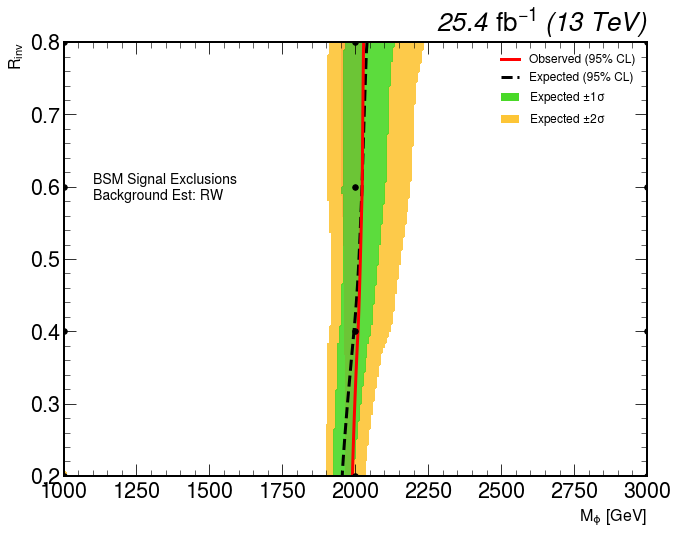

In [42]:
# Assuming optimal cuts were generated:
df_limits_rw = calculate_pyhf_limits(
    df_sig_dict=df_sig_def, 
    signal_modes=SIGNAL_MODES, 
    df_mc=df_mc_rw, 
    df_data=df_data, 
    bkg_type="RW", 
    score_cuts=opt_cut_results["RW_default"], 
    df_meta=DF_META,
    mjj_bins=MJJ_BINS, # <-- Added here
    bkg_syst_frac=0.10, 
    cut_direction="greater" # Or "greater" based on your classifier
)
# Render the 2D Brazilian plot
plot_2d_brazilian(df_limits_rw, DF_META, bkg_type="RW")

/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)


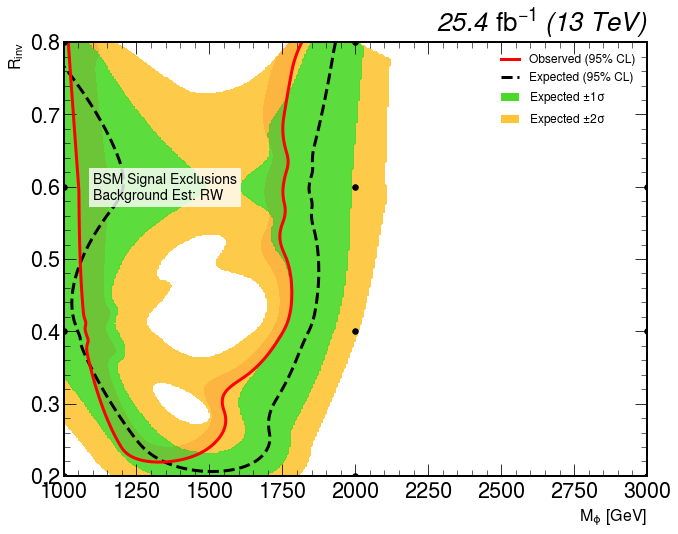

In [39]:
plot_2d_brazilian(df_limits_rw, DF_META, bkg_type="RW")

--- Running Shape Analysis pyhf Limits for Background: NOM ---
  [1000_2] Exp Limit (mu): 0.2411  |  Obs Limit (mu): 0.0314
  [1000_4] Exp Limit (mu): 0.1201  |  Obs Limit (mu): 0.0144
  [1000_6] Exp Limit (mu): 0.0791  |  Obs Limit (mu): 0.0100
  [1000_8] Exp Limit (mu): 0.0565  |  Obs Limit (mu): 0.0100
  [2000_2] Exp Limit (mu): 0.1933  |  Obs Limit (mu): 0.2753
  [2000_4] Exp Limit (mu): 0.9129  |  Obs Limit (mu): 0.2447
  [2000_6] Exp Limit (mu): 0.6865  |  Obs Limit (mu): 0.1716
  [2000_8] Exp Limit (mu): 0.5904  |  Obs Limit (mu): 0.1547
  [3000_2] Exp Limit (mu): 36.9413  |  Obs Limit (mu): 18.4708
  [3000_4] Exp Limit (mu): 17.9881  |  Obs Limit (mu): 8.3428
  [3000_6] Exp Limit (mu): 12.4859  |  Obs Limit (mu): 5.7206
  [3000_8] Exp Limit (mu): 10.3849  |  Obs Limit (mu): 5.0885


/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)


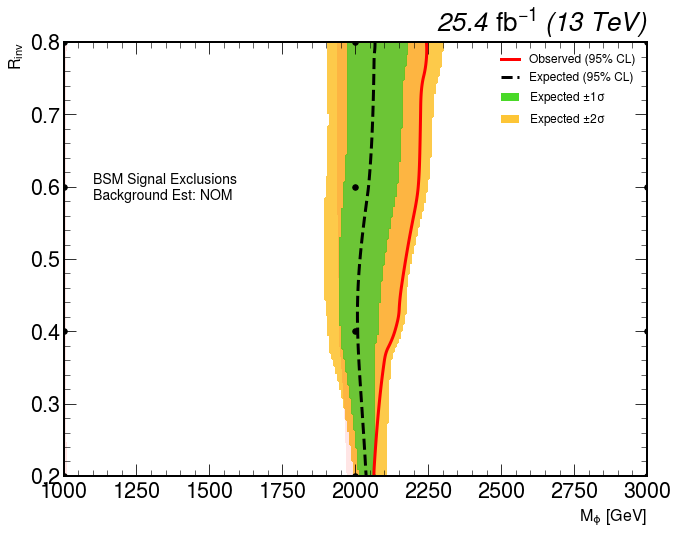

In [43]:
# Assuming optimal cuts were generated:
df_limits_nom = calculate_pyhf_limits(
    df_sig_dict=df_sig_def, 
    signal_modes=SIGNAL_MODES, 
    df_mc=df_mc_rw, 
    df_data=df_data, 
    bkg_type="NOM", 
    score_cuts=opt_cut_results["NOM_default"], 
    df_meta=DF_META,
    mjj_bins=MJJ_BINS, # <-- Added here
    bkg_syst_frac=0.10, 
    cut_direction="greater" # Or "greater" based on your classifier
)
# Render the 2D Brazilian plot
plot_2d_brazilian(df_limits_nom, DF_META, bkg_type="NOM")

In [44]:
df_limits_gen.to_csv('cwola_gen.csv', index=False)
df_limits_rw.to_csv('cwola_rw.csv', index=False)
df_limits_nom.to_csv('cwola_nom.csv', index=False)